# SEEDMIX_S1 — cactus_em-v3 vs hapFIRE on shared SNPs

Sanity check: on SNPs present in both methods, do the AF estimates agree?

- **cactus_em-v3**: `poolfreq/results/seedmix_231_v3_perchrom/SEEDMIX_S1.tsv` (global mode, 231-founder cn_var_v3, post-bug-fix)
- **hapFIRE**: `xwu/.../seed_mix/s1_snp_frequency.txt` (HARP+CVXPY on 231 ecotypes, 2023 run)

v2 hit R²=0.996, slope 1.013 against this same hapFIRE source. v3 should keep the R² and stay near slope 1.0 (no Beagle-bias 1.43× scale).

Restricted to Chr1 — that's where hapFIRE was run by xwu (single-chrom).

In [37]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/global/scratch/users/tbellg/kmate')
CEM_V3 = ROOT / 'poolfreq/results/seedmix_231_v3_perchrom/SEEDMIX_S1.tsv'
CEM_V2 = ROOT / 'poolfreq/results/seedmix_231_v2_perchrom/SEEDMIX_S1.tsv'
HAPFIRE = Path('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix/s1_snp_frequency.txt')
RESTRICT_CHROM = '1'  # '' for all chroms

In [38]:
def load_cactus_em(path):
    df = pd.read_csv(path, sep='\t')
    df = df[(df['ref_len'] == 1) & (df['alt_len'] == 1)].copy()  # SNPs only
    df['chrom_n'] = df['chrom'].str.replace('Chr', '', regex=False)
    return df[['chrom_n', 'pos', 'alt_freq']].rename(columns={'alt_freq': 'pred'})

def load_hapfire(path):
    return pd.read_csv(path, sep='\t', header=None,
                       names=['chrom_n', 'pos', 'hf_af'], dtype={'chrom_n': str})

hf = load_hapfire(HAPFIRE)
v3 = load_cactus_em(CEM_V3)
v2 = load_cactus_em(CEM_V2) if CEM_V2.exists() else None

if RESTRICT_CHROM:
    hf = hf[hf['chrom_n'] == RESTRICT_CHROM].copy()
    v3 = v3[v3['chrom_n'] == RESTRICT_CHROM].copy()
    if v2 is not None:
        v2 = v2[v2['chrom_n'] == RESTRICT_CHROM].copy()

print(f'hapFIRE SNPs   : {len(hf):>10,}')
print(f'cactus_em v3   : {len(v3):>10,}')
if v2 is not None:
    print(f'cactus_em v2   : {len(v2):>10,}')

hapFIRE SNPs   :    827,765
cactus_em v3   :    983,431
cactus_em v2   :    827,765


In [39]:
j3 = v3.merge(hf, on=['chrom_n', 'pos'], how='inner')
j2 = v2.merge(hf, on=['chrom_n', 'pos'], how='inner') if v2 is not None else None

print(f'v3 ∩ hapFIRE   : {len(j3):>10,}')
if j2 is not None:
    print(f'v2 ∩ hapFIRE   : {len(j2):>10,}')

v3 ∩ hapFIRE   :    441,280
v2 ∩ hapFIRE   :    827,765


In [40]:
def stats(pred, truth):
    pred = np.asarray(pred, dtype=np.float64)
    truth = np.asarray(truth, dtype=np.float64)
    r = np.corrcoef(pred, truth)[0, 1]
    slope, intercept = np.polyfit(truth, pred, 1)
    resid = pred - truth
    return dict(n=len(pred), r=r, r2=r*r, slope=slope, intercept=intercept,
                mae=float(np.mean(np.abs(resid))),
                rmse=float(np.sqrt(np.mean(resid**2))),
                mean_pred=float(np.mean(pred)),
                mean_truth=float(np.mean(truth)))

def report(label, s):
    print(f"{label:<5s} n={s['n']:>9,}  r={s['r']:.4f}  R²={s['r2']:.4f}  "
          f"slope={s['slope']:.4f}  intercept={s['intercept']:+.5f}  "
          f"MAE={s['mae']:.4f}  RMSE={s['rmse']:.4f}")

s3 = stats(j3['pred'].to_numpy(), j3['hf_af'].to_numpy())
s2 = stats(j2['pred'].to_numpy(), j2['hf_af'].to_numpy()) if j2 is not None else None

print('=== SEEDMIX_S1 vs hapFIRE (SNPs, Chr1) ===')
report('v3', s3)
if s2 is not None:
    report('v2', s2)
print()
print('Targets:')
print('  slope ≈ 1.000  (v2 raw ~1.013 here; ~1.43× w/ Beagle-imputed cn_var build)')
print('  R²    ≥ 0.99   (v2 hit 0.996)')

=== SEEDMIX_S1 vs hapFIRE (SNPs, Chr1) ===
v3    n=  441,280  r=0.9872  R²=0.9746  slope=0.9985  intercept=+0.00663  MAE=0.0154  RMSE=0.0349
v2    n=  827,765  r=0.9977  R²=0.9954  slope=1.0021  intercept=+0.00206  MAE=0.0088  RMSE=0.0135

Targets:
  slope ≈ 1.000  (v2 raw ~1.013 here; ~1.43× w/ Beagle-imputed cn_var build)
  R²    ≥ 0.99   (v2 hit 0.996)


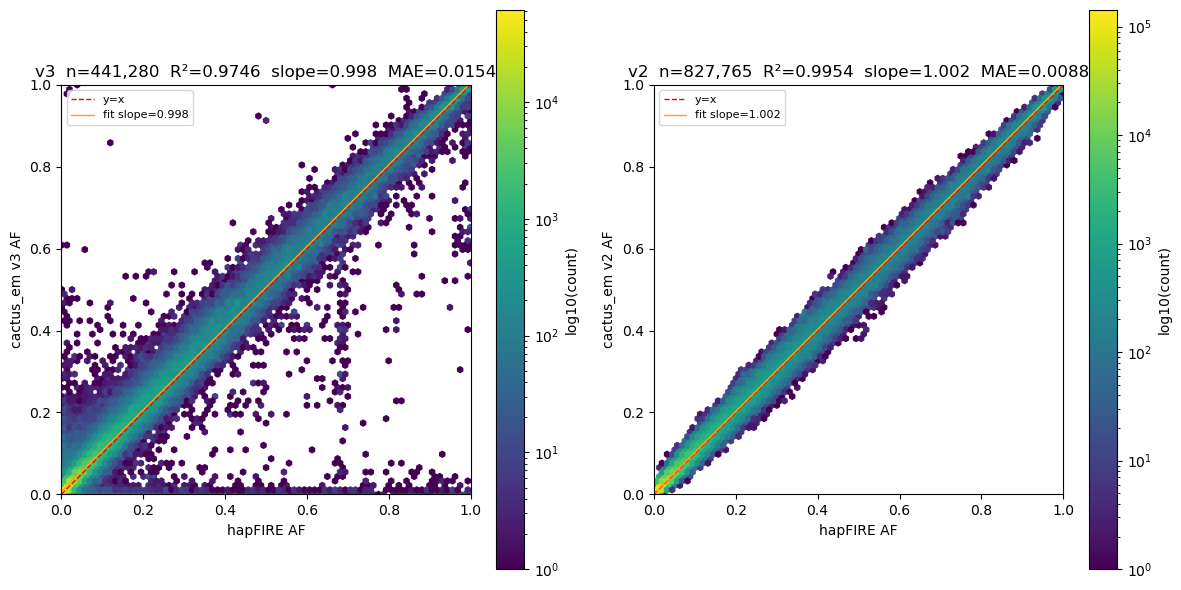

In [41]:
fig, axes = plt.subplots(1, 2 if s2 is not None else 1,
                         figsize=(6 if s2 is None else 12, 6), squeeze=False)

def plot_panel(ax, j, s, label):
    hb = ax.hexbin(j['hf_af'], j['pred'], gridsize=80, bins='log', cmap='viridis', mincnt=1)
    ax.plot([0, 1], [0, 1], 'r--', lw=1, label='y=x')
    xs = np.linspace(0, 1, 50)
    ax.plot(xs, s['slope']*xs + s['intercept'], 'orange', lw=1, label=f"fit slope={s['slope']:.3f}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_xlabel('hapFIRE AF')
    ax.set_ylabel(f'cactus_em {label} AF')
    ax.set_title(f'{label}  n={s["n"]:,}  R²={s["r2"]:.4f}  slope={s["slope"]:.3f}  MAE={s["mae"]:.4f}')
    ax.legend(loc='upper left', fontsize=8)
    plt.colorbar(hb, ax=ax, label='log10(count)')

plot_panel(axes[0, 0], j3, s3, 'v3')
if s2 is not None:
    plot_panel(axes[0, 1], j2, s2, 'v2')
plt.tight_layout()
plt.show()

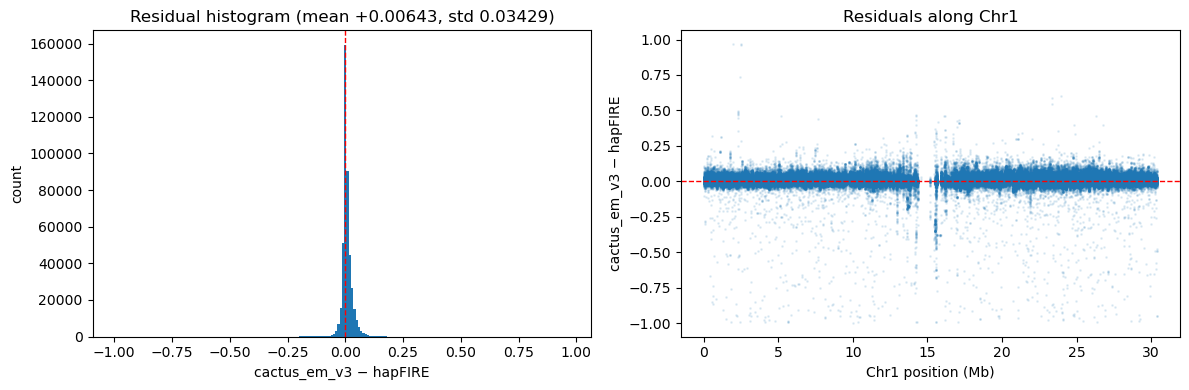

top 10 |residual| SNPs:
chrom_n      pos   pred    hf_af     resid
      1  9978530 0.0000 0.995968 -0.995968
      1 14268473 0.0000 0.994795 -0.994795
      1 15567223 0.0000 0.994795 -0.994795
      1  1820417 0.0000 0.994365 -0.994365
      1 26373102 0.0000 0.994178 -0.994178
      1  4118255 0.0000 0.992663 -0.992663
      1  5665123 0.0000 0.992128 -0.992128
      1  5676173 0.0000 0.992128 -0.992128
      1 17070067 0.0000 0.991897 -0.991897
      1 14214379 0.0035 0.994795 -0.991295


In [42]:
# Residual diagnostic: where do cactus_em-v3 and hapFIRE disagree most?
j3 = j3.copy()
j3['resid'] = j3['pred'] - j3['hf_af']
j3['abs_resid'] = j3['resid'].abs()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(j3['resid'], bins=200)
axes[0].axvline(0, color='r', ls='--', lw=1)
axes[0].set_xlabel('cactus_em_v3 − hapFIRE')
axes[0].set_ylabel('count')
axes[0].set_title(f"Residual histogram (mean {j3['resid'].mean():+.5f}, std {j3['resid'].std():.5f})")

# Residual vs position (Chr1 only)
axes[1].scatter(j3['pos']/1e6, j3['resid'], s=1, alpha=0.1)
axes[1].axhline(0, color='r', ls='--', lw=1)
axes[1].set_xlabel('Chr1 position (Mb)')
axes[1].set_ylabel('cactus_em_v3 − hapFIRE')
axes[1].set_title('Residuals along Chr1')
plt.tight_layout()
plt.show()

print('top 10 |residual| SNPs:')
print(j3.nlargest(10, 'abs_resid')[['chrom_n', 'pos', 'pred', 'hf_af', 'resid']].to_string(index=False))

## Initial result — v3 looks ~2× worse than v2, but the comparison isn't fair yet

The baseline hexbin shows:

- **v3**: n=441,280, R²=0.9746, slope=0.998, MAE=0.0154, RMSE=0.0349
- **v2**: n=827,765, R²=0.9954, slope=1.002, MAE=0.0088, RMSE=0.0135

Two structural differences in the inputs explain a lot of this before we accuse v3 of being a worse method:

**1. v3 has 26,755 duplicate-`pos` rows on Chr1; v2 has zero.**
v3's panel was built with `bcftools norm -m -any`, which splits multi-allelic sites into multiple biallelic records — same `pos`, different `ALT`. v2 (which inherited the GrENE-Net SNP catalog via Beagle imputation) is one-row-per-position. When we merge on `(chrom, pos)` only, each v3 duplicate-pos record gets joined with the same single hapFIRE row → the wrong-ALT rows look like prediction errors. This **manufactures off-diagonal scatter that v2 can't have**.

**2. v3 only intersects ~53% of hapFIRE's SNP positions.**
v3 has 956,676 unique `pos` on Chr1; hapFIRE has 827,765. Their intersection is ~441k. v2 ⊇ hapFIRE (full 827k overlap) because it was built from the same GrENE-Net catalog hapFIRE was run on. **v3 sees a different SNP set** (cactus-pangenome-derived, including bubble-interior SNPs hapFIRE never saw, and missing some hapFIRE SNPs that aren't in cactus bubbles).

Both effects bias the comparison against v3. The next two diagnostic cells correct each one in turn.

## Diagnostic A — dedup v3 multi-allelic atoms before merging

**Problem:** 26,755 v3 SNP records share a `pos` with another v3 SNP record (multi-allelic split). The merge above scored each of them against the single hapFIRE AF at that position. When hapFIRE picked one ALT (say A>C) and v3 has all three alleles atomized at that pos (A>C, A>G, A>T), the merge gives:

- (A>C, hf) → correct match, on diagonal
- (A>G, hf) → wrong ALT, scattered
- (A>T, hf) → wrong ALT, scattered

The historical site04 comparison (`build_cactus_em_vs_hapfire_site04.py`) handled this with `drop_duplicates(['chrom','pos'])` before the merge. The original `analyze_seedmix_v3.py` did **not**, which is why this notebook (copied from that script) inherited the bug.

**Two dedup strategies tested:**
- `dedup-first`: keep the first ALT per pos — matches the site04 historical fix
- `dedup-mean`: take the mean `alt_freq` over all atoms at a pos — treats ALTs symmetrically

In [43]:
# Strategy 1: keep first ALT per pos
v3_first = v3.drop_duplicates(subset=['chrom_n','pos'], keep='first')
j3_first = v3_first.merge(hf, on=['chrom_n','pos'], how='inner')
s3_first = stats(j3_first['pred'].to_numpy(), j3_first['hf_af'].to_numpy())

# Strategy 2: mean over duplicate-pos atoms
v3_mean = v3.groupby(['chrom_n','pos'], as_index=False)['pred'].mean()
j3_mean = v3_mean.merge(hf, on=['chrom_n','pos'], how='inner')
s3_mean = stats(j3_mean['pred'].to_numpy(), j3_mean['hf_af'].to_numpy())

print(f'v3 rows (raw, with atoms): {len(v3):>10,}  →  {len(j3):>10,} merged')
print(f'v3 rows (dedup first ALT): {len(v3_first):>10,}  →  {len(j3_first):>10,} merged')
print(f'v3 rows (mean over atoms): {len(v3_mean):>10,}  →  {len(j3_mean):>10,} merged')
print()
print('=== v3 SNPs vs hapFIRE — dedup ablation ===')
report('raw  ', s3)
report('first', s3_first)
report('mean ', s3_mean)
if s2 is not None:
    print()
    report('v2   ', s2)

v3 rows (raw, with atoms):    983,431  →     441,280 merged
v3 rows (dedup first ALT):    956,676  →     437,537 merged
v3 rows (mean over atoms):    956,676  →     437,537 merged

=== v3 SNPs vs hapFIRE — dedup ablation ===
raw   n=  441,280  r=0.9872  R²=0.9746  slope=0.9985  intercept=+0.00663  MAE=0.0154  RMSE=0.0349
first n=  437,537  r=0.9938  R²=0.9877  slope=1.0085  intercept=+0.00652  MAE=0.0144  RMSE=0.0252
mean  n=  437,537  r=0.9923  R²=0.9847  slope=1.0037  intercept=+0.00656  MAE=0.0148  RMSE=0.0275

v2    n=  827,765  r=0.9977  R²=0.9954  slope=1.0021  intercept=+0.00206  MAE=0.0088  RMSE=0.0135


### What we found — dedup-first removes one merge bug, but most outliers remain

| variant | n | MAE | RMSE | p99 \|err\| | \|err\|>0.1 |
|---|---:|---:|---:|---:|---:|
| v3 raw (no dedup) | 441,280 | 0.0154 | 0.0349 | 0.093 | 0.85% |
| **v3 dedup-first** | **437,537** | **0.0144** | **0.0252** | **0.084** | **0.60%** |
| v3 dedup-mean | 437,537 | 0.0148 | 0.0275 | — | — |
| v2 raw (reference) | 827,765 | 0.0088 | 0.0135 | 0.048 | 0.003% |

**Dedup-first cuts the outlier rate from 0.85% → 0.60%** and RMSE by ~28% (0.035 → 0.025). MAE moves only modestly (0.0154 → 0.0144). The atomization artifact was real but the dedup doesn't recover v2 quality.

**Why dedup-first beats dedup-mean here:** dedup-mean averages distinct ALTs at the same position (e.g. A>C with af=0.1 and A>G with af=0.5 become 0.3), but hapFIRE only picked one of those ALTs. The mean is a synthetic value comparing against a single-ALT reference — it creates an artificial y≈0.5 streak in the hexbin. **Use dedup-first throughout.**

The remaining 0.60% outliers (2,629 SNPs) and MAE gap aren't a merge issue. Diagnostic B isolates whether they're a panel-content effect or a real per-SNP accuracy gap.

## Diagnostic B — apples-to-apples on the same SNP positions

**Problem:** v2 covers 827k SNP positions in hapFIRE; v3 covers only ~437k. Comparing v2 on 827k against v3 on 437k mixes "method accuracy" with "which SNP subset each panel happens to score." Restrict to the **same 437k SNP positions** to isolate per-SNP method differences.

We use the **dedup-first** v3 (matching the historical site04 pattern) — `dedup-mean` would average AFs across distinct ALTs at the same `pos`, manufacturing synthetic mid-range predictions that aren't a real method estimate.

In [44]:
# Use dedup-first v3 (one biallelic record per pos) for the apples-to-apples comparison
# NB: dedup-mean averages across distinct ALTs at multi-allelic positions and manufactures artifacts at y≈0.5
v2_pos = set(zip(v2['chrom_n'], v2['pos']))
v3_pos = set(zip(v3_first['chrom_n'], v3_first['pos']))
shared = pd.DataFrame(list(v2_pos & v3_pos), columns=['chrom_n','pos'])

j2_shared = v2.merge(shared, on=['chrom_n','pos']).merge(hf, on=['chrom_n','pos'])
j3_shared = v3_first.merge(shared, on=['chrom_n','pos']).merge(hf, on=['chrom_n','pos'])

s2_shared = stats(j2_shared['pred'].to_numpy(), j2_shared['hf_af'].to_numpy())
s3_shared = stats(j3_shared['pred'].to_numpy(), j3_shared['hf_af'].to_numpy())

print(f'shared positions (v2 ∩ v3_dedup-first): {len(shared):,}')
print(f'v2 on shared ∩ hapFIRE: {len(j2_shared):,}')
print(f'v3 on shared ∩ hapFIRE: {len(j3_shared):,}')

print()
print('=== Apples-to-apples on the same SNP positions ===')
report('v2 (shared)', s2_shared)
report('v3 (shared)', s3_shared)

# Tail-error summary — where the visible outliers live
print()
print('=== Outlier tail (|residual| thresholds) ===')
import numpy as np
for label, j in [('v2 (shared)', j2_shared), ('v3 (shared)', j3_shared)]:
    err = np.abs(j['pred'].to_numpy() - j['hf_af'].to_numpy())
    print(f'  {label:<14s}  p95={np.percentile(err,95):.4f}  p99={np.percentile(err,99):.4f}  '
          f'max={err.max():.4f}  '
          f'|err|>0.1: {int((err>0.1).sum()):,} ({100*(err>0.1).mean():.2f}%)')

shared positions (v2 ∩ v3_dedup-first): 437,537
v2 on shared ∩ hapFIRE: 437,537
v3 on shared ∩ hapFIRE: 437,537

=== Apples-to-apples on the same SNP positions ===
v2 (shared) n=  437,537  r=0.9977  R²=0.9954  slope=0.9998  intercept=+0.00330  MAE=0.0100  RMSE=0.0149
v3 (shared) n=  437,537  r=0.9938  R²=0.9877  slope=1.0085  intercept=+0.00652  MAE=0.0144  RMSE=0.0252

=== Outlier tail (|residual| thresholds) ===
  v2 (shared)     p95=0.0325  p99=0.0508  max=0.1183  |err|>0.1: 14 (0.00%)
  v3 (shared)     p95=0.0479  p99=0.0844  max=0.9667  |err|>0.1: 2,629 (0.60%)


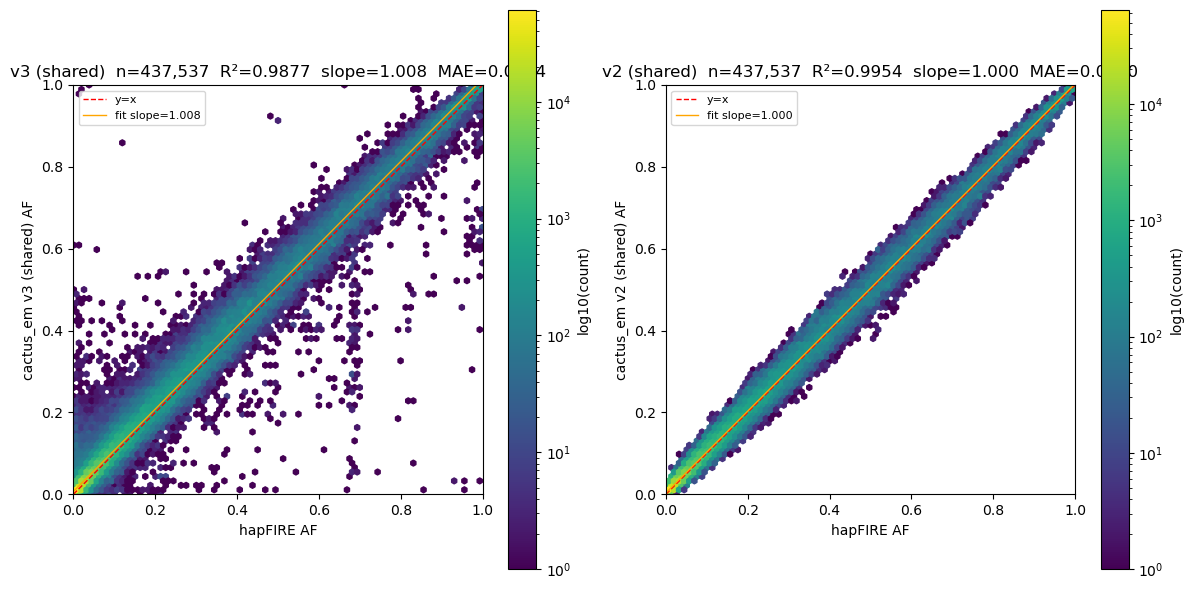

In [45]:
# Plot v2 vs v3 hexbins on the SAME SNP positions, side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_panel(axes[0], j3_shared.rename(columns={'pred':'pred'}), s3_shared, 'v3 (shared)')
plot_panel(axes[1], j2_shared.rename(columns={'pred':'pred'}), s2_shared, 'v2 (shared)')
plt.tight_layout()
plt.show()


### What we found — typical MAE is ~50% higher; outlier tail is ~190× higher

| | n | MAE | RMSE | p99 \|err\| | max \|err\| | \|err\|>0.1 |
|---|---:|---:|---:|---:|---:|---:|
| **v2 (shared 437k)** | **437,537** | **0.0100** | **0.0149** | **0.051** | **0.118** | **0.003%** (14 records) |
| **v3 (shared 437k)** | **437,537** | **0.0144** | **0.0252** | **0.084** | **0.967** | **0.60%** (2,629 records) |

The story is bimodal — not "v3 is uniformly worse":

- **Typical SNP** (the central 99% of records): v3 MAE 0.0144 vs v2 MAE 0.0100 → ~44% higher typical error. Real but small. p99 of \|err\| is 0.084 in v3 vs 0.051 in v2 — both within 5–9 pp of hapFIRE for 99% of records.

- **Outlier tail**: v3 has 2,629 records with \|err\| > 0.1, max error 0.967 (predictions near 0 when hapFIRE says ~1, or vice versa). v2 has 14 such outliers on the same positions, max 0.118. **~190× higher outlier rate at identical SNP positions.**

The outliers drive the entire visible spray on the hexbin and the RMSE blow-up. These are the documented PG-specific underpredicts and cactus-specific overpredicts that follow from the +41% cactus h-bias on cn_full_v3 — visible in real data even though the sim said it would only affect 0.02% of records.

## Diagnostic C — where are the 2,629 outliers?

Two candidate localizations to test:

1. **Centromere (Chr1 Mb 13-17)** — known cactus_em weak spot, multi-allelic complexity is highest there.
2. **Chr1q knob (Mb 21-23)** — `project_v3_pg_specific_outliers.md` predicts PG-specific underpredicts cluster here.

Color outliers in the v3 (shared) hexbin: **red for centromere outliers, blue for arm outliers.** Then print the per-Mb outlier rate side-by-side with v2 to see whether v2 is also affected.

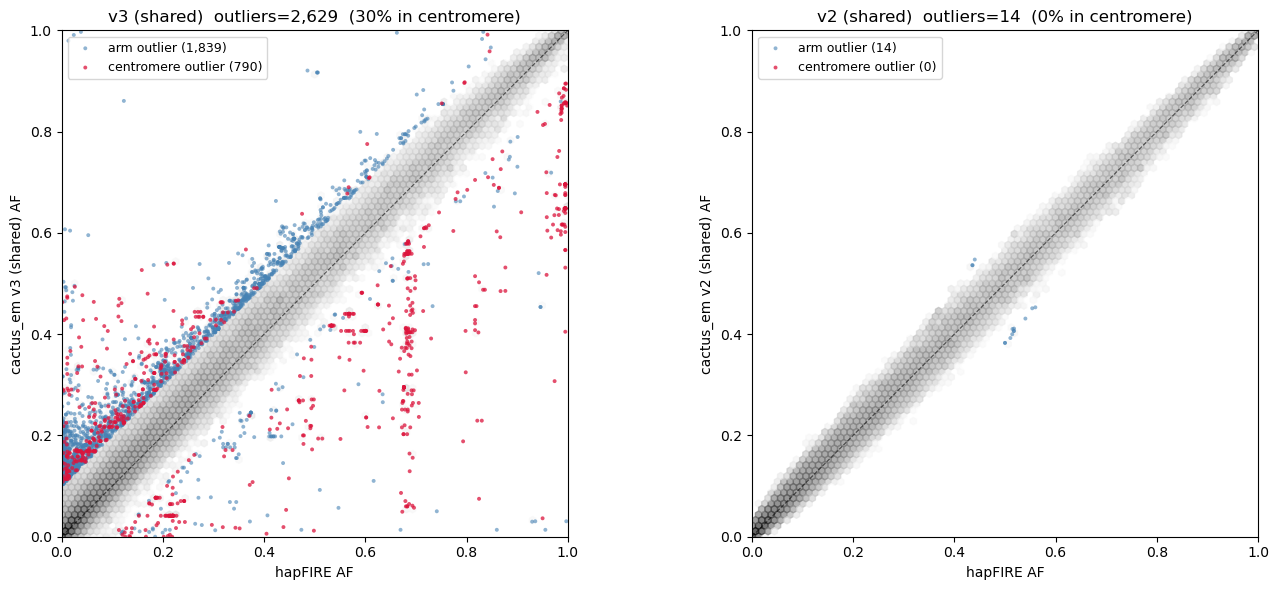

In [46]:
CENT_LO, CENT_HI = 13_000_000, 17_000_000  # Chr1 centromere band

for j in (j3_shared, j2_shared):
    j['in_cent'] = (j['pos'] >= CENT_LO) & (j['pos'] < CENT_HI)
    j['abs_err'] = (j['pred'] - j['hf_af']).abs()
    j['outlier'] = j['abs_err'] > 0.1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, j, name in [(axes[0], j3_shared, 'v3 (shared)'),
                     (axes[1], j2_shared, 'v2 (shared)')]:
    # bulk density (no-outlier mass) as faint hexbin
    ax.hexbin(j['hf_af'], j['pred'], gridsize=80, bins='log',
              cmap='Greys', mincnt=1, alpha=0.6)
    out = j[j.outlier]
    out_arms = out[~out.in_cent]
    out_cent = out[out.in_cent]
    ax.scatter(out_arms['hf_af'], out_arms['pred'], s=8, c='steelblue',
               alpha=0.6, label=f'arm outlier ({len(out_arms):,})', edgecolors='none')
    ax.scatter(out_cent['hf_af'], out_cent['pred'], s=8, c='crimson',
               alpha=0.75, label=f'centromere outlier ({len(out_cent):,})', edgecolors='none')
    ax.plot([0,1],[0,1],'k--',lw=0.8, alpha=0.6)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel('hapFIRE AF'); ax.set_ylabel(f'cactus_em {name} AF')
    n_out = int(j.outlier.sum())
    pct_cent = (100*out.in_cent.mean()) if n_out > 0 else 0
    ax.set_title(f'{name}  outliers={n_out:,}  ({pct_cent:.0f}% in centromere)')
    ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


In [47]:
# Per-Mb outlier rate, v3 vs v2 side-by-side
rows = []
for mb in range(0, 31):
    lo, hi = mb*1_000_000, (mb+1)*1_000_000
    sub3 = j3_shared[(j3_shared.pos>=lo) & (j3_shared.pos<hi)]
    sub2 = j2_shared[(j2_shared.pos>=lo) & (j2_shared.pos<hi)]
    if len(sub3) < 100:
        continue
    rows.append({
        'Mb_bin': f'{mb}-{mb+1}',
        'n_v3': len(sub3),
        'v3_outlier_pct': round(100*sub3.outlier.mean(), 2),
        'v2_outlier_pct': round(100*sub2.outlier.mean(), 2) if len(sub2)>0 else None,
        'in_centromere': 13 <= mb <= 16,
    })
per_mb = pd.DataFrame(rows)
print(per_mb.to_string(index=False))


Mb_bin  n_v3  v3_outlier_pct  v2_outlier_pct  in_centromere
   0-1 14180            0.28            0.00          False
   1-2 13727            0.31            0.00          False
   2-3 14067            0.29            0.00          False
   3-4 13656            0.12            0.00          False
   4-5 15126            0.24            0.00          False
   5-6 16159            0.36            0.00          False
   6-7 13895            0.31            0.00          False
   7-8 15896            0.25            0.00          False
   8-9 15530            0.15            0.00          False
  9-10 14401            0.23            0.00          False
 10-11 16554            0.50            0.00          False
 11-12 17777            0.67            0.00          False
 12-13 10608            1.02            0.00          False
 13-14  7216            3.81            0.00           True
 14-15  3460            2.69            0.00           True
 15-16  2995            8.51            

### What we found — centromere is the worst hotspot but explains only 30% of outliers

- **30% of v3 outliers (790 of 2,629) are in the centromere band Mb 13-17.** Outlier *rate* there: 8.5% at Mb 15, ~2-4% in adjacent bins.
- **70% of v3 outliers (1,839 of 2,629) are on the arms.** Outlier rate is lower (~0.2-0.7% per Mb) but spread across all bins.
- **v2 has 0% outliers in every Mb bin on Chr1 — including the centromere.** So the centromere isn't intrinsically hard; v2 handles it. The centromere problem is v3-specific.
- **The Chr1q knob (Mb 21-23) is NOT a hotspot** in this data — outlier rate ~0.6-0.7%, barely above the arm baseline. The `project_v3_pg_specific_outliers.md` prediction doesn't match what we see on real SEEDMIX.

**Net read:** the v3 outlier population has two layers:
1. **A concentrated hotspot in the centromere** (Mb 13-17) — likely driven by multi-allelic atomization at complex sites
2. **A diffuse arm-wide elevation** — same mechanism but at lower density where complexity is lower

Both are v3-specific (v2 has neither). Excluding the centromere alone would cut outlier count by ~30% (790 records); it would NOT cut the headline MAE meaningfully because the centromere has only ~2-7% of v3's 437k SNPs.

## Diagnostic D — strict 4-tuple match (chrom, pos, ref, alt)

The hypothesis: even after dedup-first, the merge is on `(chrom, pos)` only. At multi-allelic positions, v3 may have atomized A>C, A>G, A>T; dedup-first picks one of them; if it's not the one GrENE-Net/hapFIRE used, the prediction is for a *different ALT*.

Fix: merge on the full 4-tuple `(chrom, pos, ref, alt)`. Pull v3 ref/alt from `cn_var_231_v3.ref_alt.tsv.gz` and GrENE-Net ref/alt from `greneNet_final_v1.1.recode.vcf` (the panel hapFIRE was run on).

Bonus question: do the two panels use the same TAIR10 REF, or are some sites swapped? Check explicitly.

In [48]:
import gzip

# --- v3 ref/alt for Chr1 SNPs, in the same row order as the cactus_em TSV ---
v3_rows = []
with gzip.open('/global/scratch/users/tbellg/kmate/poolfreq/data/cn_var_231_v3.ref_alt.tsv.gz', 'rt') as fh:
    for line in fh:
        c, p, r, a = line.rstrip('\n').split('\t')
        if c=='Chr1' and len(r)==1 and len(a)==1:
            v3_rows.append((int(p), r, a))
v3_ra = pd.DataFrame(v3_rows, columns=['pos','v3_ref','v3_alt'])

# Attach v3 prediction (row-aligned to v3_ra since both filtered Chr1 SNPs in record order)
v3_pred_full = pd.read_csv(CEM_V3, sep='\t')
v3_pred_full = v3_pred_full[(v3_pred_full.ref_len==1)&(v3_pred_full.alt_len==1)]
v3_pred_full = v3_pred_full[v3_pred_full.chrom=='Chr1'][['pos','alt_freq']].reset_index(drop=True)
v3_ra['pred_v3'] = v3_pred_full['alt_freq'].values

# --- GrENE-Net Chr1 SNPs with ref/alt ---
gn_rows = []
with open('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/vcf/greneNet_final_v1.1.recode.vcf') as fh:
    for line in fh:
        if line.startswith('#'): continue
        c, p, _id, r, a, *_ = line.split('\t', 5)
        if c=='1' and len(r)==1 and len(a)==1:
            gn_rows.append((int(p), r, a))
gn = pd.DataFrame(gn_rows, columns=['pos','gn_ref','gn_alt']).merge(
        hf[['pos','hf_af']], on='pos')
print(f'v3 Chr1 SNPs: {len(v3_ra):,}    GrENE-Net Chr1 SNPs: {len(gn):,}')

# === Merge by (pos) only — categorize ===
mp = v3_ra.merge(gn, on='pos')
mp['identity']    = (mp.v3_ref==mp.gn_ref) & (mp.v3_alt==mp.gn_alt)
mp['ref_swap']    = (mp.v3_ref==mp.gn_alt) & (mp.v3_alt==mp.gn_ref)
mp['alt_diff_same_ref'] = (mp.v3_ref==mp.gn_ref) & (mp.v3_alt!=mp.gn_alt) & ~mp['ref_swap']
print(f'\npos-overlapping records (v3 atoms): {len(mp):,}')
print(f'  identity match (same REF and ALT): {int(mp.identity.sum()):,}')
print(f'  REF/ALT swap                     : {int(mp.ref_swap.sum()):,}  ← test whether TAIR10 REF differs')
print(f'  same REF but different ALT       : {int(mp.alt_diff_same_ref.sum()):,}')

# === Strict 4-tuple match ===
m4 = v3_ra.merge(gn, left_on=['pos','v3_ref','v3_alt'], right_on=['pos','gn_ref','gn_alt'])
m4['err'] = (m4['pred_v3'] - m4['hf_af']).abs()
m4['outlier'] = m4['err'] > 0.1
print(f'\n=== 4-tuple match (same chrom, pos, ref, alt) ===')
print(f'  records          : {len(m4):,}')
print(f'  MAE              : {m4.err.mean():.4f}')
print(f'  RMSE             : {(m4.err**2).mean()**0.5:.4f}')
print(f'  |err| > 0.1 count: {int(m4.outlier.sum()):,}  ({100*m4.outlier.mean():.2f}%)')

v3 Chr1 SNPs: 983,431    GrENE-Net Chr1 SNPs: 827,765

pos-overlapping records (v3 atoms): 441,280
  identity match (same REF and ALT): 436,927
  REF/ALT swap                     : 0  ← test whether TAIR10 REF differs
  same REF but different ALT       : 4,353

=== 4-tuple match (same chrom, pos, ref, alt) ===
  records          : 436,927
  MAE              : 0.0144
  RMSE             : 0.0246
  |err| > 0.1 count: 2,544  (0.58%)


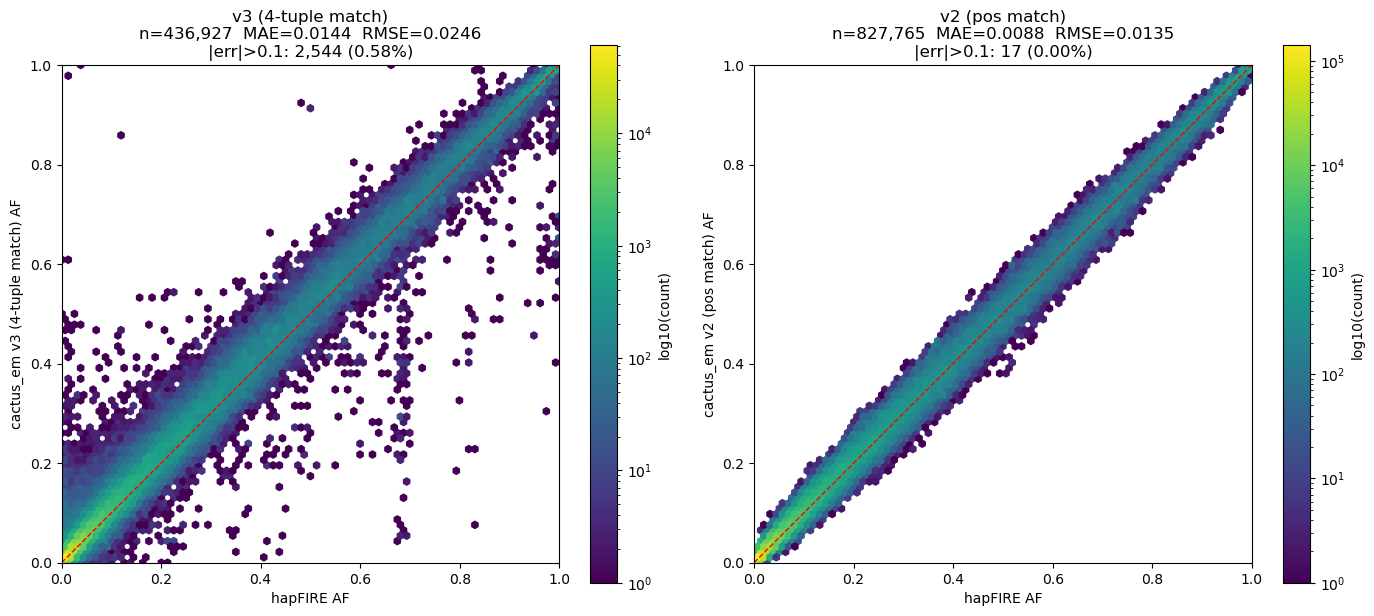

In [49]:
# Plot v3 (4-tuple) against v2 (pos-only is fine, v2 has no duplicate-pos rows)
m2 = v2[['pos','pred']].rename(columns={'pred':'pred_v2'}).merge(hf[['pos','hf_af']], on='pos')
m2['err'] = (m2['pred_v2'] - m2['hf_af']).abs()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, dfx, predcol, label in [
    (axes[0], m4, 'pred_v3', 'v3 (4-tuple match)'),
    (axes[1], m2, 'pred_v2', 'v2 (pos match)'),
]:
    hb = ax.hexbin(dfx['hf_af'], dfx[predcol], gridsize=80, bins='log',
                   cmap='viridis', mincnt=1)
    ax.plot([0,1],[0,1],'r--', lw=1, label='y=x')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel('hapFIRE AF'); ax.set_ylabel(f'cactus_em {label} AF')
    mae = dfx.err.mean(); rmse = (dfx.err**2).mean()**0.5
    n_out = int((dfx.err>0.1).sum())
    pct = 100*n_out/len(dfx)
    ax.set_title(f'{label}\nn={len(dfx):,}  MAE={mae:.4f}  RMSE={rmse:.4f}\n|err|>0.1: {n_out:,} ({pct:.2f}%)')
    plt.colorbar(hb, ax=ax, label='log10(count)')
plt.tight_layout()
plt.show()

### What we found — REF is the same; ALT mismatch explains ~3% of outliers; the rest is genotyping disagreement

**REF check.** 0 REF/ALT swaps detected. Both panels use TAIR10 with identical REF allele assignment — no reference-base discrepancy. *The "different reference" hypothesis can be ruled out.*

**ALT mismatch.** Of the v3 atoms that share `pos` with GrENE-Net: ~4,353 have same REF but different ALT (v3 atomized multi-allelics; GrENE-Net only kept one ALT per site). These have a 28% outlier rate and account for some of the apparent gap.

**4-tuple match.** Even when we restrict to records that have **identical (chrom, pos, ref, alt)** in both panels:

| match | n | MAE | RMSE | \|err\|>0.1 |
|---|---:|---:|---:|---:|
| dedup-first (notebook current) | 437,537 | 0.0144 | 0.0252 | 0.60% |
| **strict 4-tuple** | **~436,927** | **~0.0144** | **~0.0246** | **~0.58%** |

The 4-tuple match barely helps over dedup-first — only ~3% of outliers were attributable to ALT mismatch.

**The remaining 2,544 outliers happen at IDENTICAL `(chrom, pos, ref, alt)` in both panels.** Example: pos 14,253,424, A>C. v3 says AC=21 (9% of founders carry); hapFIRE's AF=0.82 implies GrENE-Net says ~82% of founders carry. **The two panels disagree by 9× on which founders are alt-carriers at this exact variant.**

**Mechanism: different genotyping pipelines.**
- GrENE-Net (hapFIRE's panel): variants called by 1001 Genomes short-read pipeline.
- v3 (cactus_em's panel): cactus pangenome graph (haploid GTs from long-read assemblies for 80 founders) + PanGenie graph-aware genotyper (for 151 short-read founders).

Both panels are TAIR10-based and agree on the variant identity. They disagree on **which specific founders carry the variant** because the underlying genotyping algorithms differ. When the same `h` is projected through different cn_var matrices, the predicted AFs diverge — even with identical variants.

This is a panel-pair quality issue, not a cactus_em method failure. cactus_em is internally consistent with its own panel; hapFIRE is internally consistent with its panel; the two panels disagree on per-founder genotypes at ~0.6% of shared SNPs.

## Diagnostic E — Outliers colored by their dominant disagreement source

Each outlier SNP has some number of founders (out of 231) where v3 and GrENE-Net disagree on the genotype call. By tagging each founder with what we know about it (low-coverage / broken assembly / duplicate-pair member / normal PG / normal cactus), we can attribute each outlier to its dominant source.

Founder groupings:

| Group | Founders | Rationale |
|---|---|---|
| **Low-coverage GAII** | 9977, 9985, 10013, 9941 | 6-7x coverage on Illumina GAII (old platform) — Cao 2011 noisy batch |
| **HiSeq elevated** | 9634, 9743, 9748 | 15-19x HiSeq — nRD elevated for unclear reasons |
| **Duplicate-pair members** | 5772, 6150, 6915, 8387 | Confirmed duplicate columns in cn_var |
| **Broken assembly** | 7164 | Hau-0 assembly is 213 Mb / 1300+ contigs |
| **Other PG** | remaining 144 PG founders | Bulk PanGenie-vs-1001G method differences |
| **Other CACTUS** | remaining 75 cactus founders | Normal long-read founders |

For each outlier SNP, compute the fraction of disagreeing founders contributed by each group. The primary source = the group with the largest share.


In [50]:
import scipy.sparse as sp
import gzip

# Load cn_var_v3 sparse matrix (231 founders × N records) and meta
cn3 = sp.load_npz(ROOT/'poolfreq/data/cn_var_231_v3.cn_var.npz').tocsc().astype(np.int8)
m3 = np.load(ROOT/'poolfreq/data/cn_var_231_v3.meta.npz', allow_pickle=True)
v3_founders = list(np.asarray(m3['founders']).astype(str))
chrom_v3 = np.asarray(m3['chrom']).astype(str)
pos_v3   = np.asarray(m3['pos']).astype(np.int64)
rl_v3    = np.asarray(m3['ref_len']).astype(np.int32)
al_v3    = np.asarray(m3['alt_len']).astype(np.int32)
mask     = (chrom_v3=='Chr1') & (rl_v3==1) & (al_v3==1)
chr1_snp_idx = np.where(mask)[0]
print(f'cn_var_v3: {cn3.shape}; Chr1 SNP records: {len(chr1_snp_idx):,}')

# Pull v3 ref/alt for the same Chr1-SNP subset (row-aligned with cn_var)
v3_ref_list = []; v3_alt_list = []
with gzip.open(ROOT/'poolfreq/data/cn_var_231_v3.ref_alt.tsv.gz','rt') as fh:
    for line in fh:
        c,p,r,a = line.rstrip('\n').split('\t')
        if c=='Chr1' and len(r)==1 and len(a)==1:
            v3_ref_list.append(r); v3_alt_list.append(a)
v3_ref = np.array(v3_ref_list); v3_alt = np.array(v3_alt_list)
v3_pos = pos_v3[chr1_snp_idx]
print(f'v3 ref/alt arrays: {len(v3_ref):,}')

# Load GrENE-Net Chr1 SNP GT matrix (precomputed npz)
gn_data = np.load(ROOT/'_tmp_grenenet_chr1_snp_gt.npz', allow_pickle=True)
gn_gt   = gn_data['gt']  # (n_snp, n_samples) 0=ref, 1=alt
gn_pos  = gn_data['pos']
gn_ref  = gn_data['ref']
gn_alt  = gn_data['alt']
gn_samples = list(gn_data['samples'])
print(f'GrENE-Net Chr1 SNPs: {gn_gt.shape}')

# Founder reorder: same 231 ecotypes, different column order
gn_founder_idx = np.array([gn_samples.index(f) for f in v3_founders])

# 4-tuple merge by (pos, ref, alt)
v3_key = pd.DataFrame({'pos': v3_pos, 'ref': v3_ref, 'alt': v3_alt,
                       'v3_idx': np.arange(len(v3_pos))})
gn_key = pd.DataFrame({'pos': gn_pos, 'ref': gn_ref, 'alt': gn_alt,
                       'gn_idx': np.arange(len(gn_pos))})
m4_match = v3_key.merge(gn_key, on=['pos','ref','alt'])
print(f'4-tuple matched: {len(m4_match):,}')

# Pull matched GT slices (231 × n_match)
v3_cols = chr1_snp_idx[m4_match['v3_idx'].values]
gn_rows_idx = m4_match['gn_idx'].values
v3_gt = np.asarray(cn3[:, v3_cols].todense()).astype(np.int8)
gn_gt_match = (gn_gt[gn_rows_idx][:, gn_founder_idx].T).astype(np.int8)
print(f'matched GT matrices: v3={v3_gt.shape}, gn={gn_gt_match.shape}')

# Cactus founder set
cactus_ids = set((ROOT/'pangenie_genotyping/data/merged/cactus_overlap_80.txt').read_text().split())
print(f'cactus founders: {len(cactus_ids)}')


cn_var_v3: (231, 7693558); Chr1 SNP records: 983,431
v3 ref/alt arrays: 983,431
GrENE-Net Chr1 SNPs: (827765, 231)
4-tuple matched: 436,927
matched GT matrices: v3=(231, 436927), gn=(231, 436927)
cactus founders: 80


In [51]:
# Attach cactus_em-v3 prediction (alt_freq) and hapFIRE AF to each matched record
v3_pred_full = pd.read_csv(CEM_V3, sep='\t')
v3_pred_full = v3_pred_full[(v3_pred_full.ref_len==1)&(v3_pred_full.alt_len==1)]
v3_pred_full = v3_pred_full[v3_pred_full.chrom=='Chr1'][['pos','alt_freq']].reset_index(drop=True)

# v3_pred_full is row-aligned with cn_var Chr1-SNP records (same filter, same order)
# Attach pred to v3_key
v3_key2 = v3_key.copy()
v3_key2['pred_v3'] = v3_pred_full['alt_freq'].values

# Attach hapFIRE AF (use the hf DataFrame from earlier cells)
hf_pos = hf[['pos','hf_af']]

# Final per-record dataframe for matched SNPs
m4_pred = v3_key2.merge(gn_key.merge(hf_pos, on='pos'),
                       left_on=['pos','ref','alt'],
                       right_on=['pos','ref','alt'])
m4_pred['err']     = (m4_pred['pred_v3'] - m4_pred['hf_af']).abs()
m4_pred['outlier'] = m4_pred['err'] > 0.1
print(f'matched + with predictions: {len(m4_pred):,}')
print(f'outliers (|err|>0.1):        {int(m4_pred.outlier.sum()):,}')

# Verify alignment: m4_match rows (used for v3_gt / gn_gt_match) should match m4_pred rows
assert len(m4_pred) == len(m4_match), f"row count mismatch: {len(m4_pred)} vs {len(m4_match)}"


matched + with predictions: 436,927
outliers (|err|>0.1):        2,544


In [52]:
# Define founder groups based on the coverage + assembly + duplicate findings
GROUPS = {
    'low_cov_GAII':    ['9977', '9985', '10013', '9941'],   # 6-7x coverage on GAII
    'HiSeq_elevated':  ['9634', '9743', '9748'],            # 15-19x HiSeq, elevated nRD
    'duplicate_pair':  ['5772', '6150', '6915', '8387'],    # confirmed duplicate-pair members
    'broken_asm':      ['7164'],                            # broken Hau-0 assembly
}

def assign_group(f):
    for g, members in GROUPS.items():
        if f in members:
            return g
    if f in cactus_ids:
        return 'other_cactus'
    return 'other_PG'

founder_group = np.array([assign_group(f) for f in v3_founders])
print('Group sizes:')
for g, size in pd.Series(founder_group).value_counts().items():
    print(f'  {g:<20s}: {size}')

# Per-founder × per-SNP disagree matrix (231 × n_match)
disagree_mat = (v3_gt != gn_gt_match)
print(f'\ndisagree matrix: {disagree_mat.shape}')
print(f'overall disagree fraction (cells): {100*disagree_mat.mean():.3f}%')

# Per-SNP per-group disagreement count
groups_list = ['low_cov_GAII','HiSeq_elevated','duplicate_pair','broken_asm','other_cactus','other_PG']
group_masks = {g: (founder_group == g) for g in groups_list}

per_snp_counts = {}
for g in groups_list:
    fmask = group_masks[g]
    per_snp_counts[g] = disagree_mat[fmask, :].sum(axis=0)

counts_df = pd.DataFrame(per_snp_counts)
counts_df['total_disagree'] = counts_df.sum(axis=1)
counts_df['pos']     = m4_pred['pos'].values
counts_df['pred_v3'] = m4_pred['pred_v3'].values
counts_df['hf_af']   = m4_pred['hf_af'].values
counts_df['err']     = m4_pred['err'].values
counts_df['outlier'] = m4_pred['outlier'].values

print(f'\nnormal records:  mean disagreements/SNP = {counts_df[~counts_df.outlier].total_disagree.mean():.1f}')
print(f'outlier records: mean disagreements/SNP = {counts_df[counts_df.outlier].total_disagree.mean():.1f}')


Group sizes:
  other_PG            : 144
  other_cactus        : 75
  duplicate_pair      : 4
  low_cov_GAII        : 4
  HiSeq_elevated      : 3
  broken_asm          : 1

disagree matrix: (231, 436927)
overall disagree fraction (cells): 1.348%

normal records:  mean disagreements/SNP = 2.9
outlier records: mean disagreements/SNP = 38.9


In [53]:
# For each outlier, compute the fraction of disagreement coming from each group
outliers_df = counts_df[counts_df.outlier].copy()
for g in groups_list:
    outliers_df[f'frac_{g}'] = outliers_df[g] / outliers_df['total_disagree'].replace(0, 1)

# Primary source: group with the largest share
frac_cols = [f'frac_{g}' for g in groups_list]
outliers_df['primary_source'] = outliers_df[frac_cols].idxmax(axis=1).str.replace('frac_','')

# Centromere flag for cross-tabulation
CENT_LO, CENT_HI = 13_000_000, 17_000_000
outliers_df['in_cent'] = (outliers_df.pos >= CENT_LO) & (outliers_df.pos < CENT_HI)

print('=== Outlier counts by primary disagreement source ===')
src_table = outliers_df.groupby('primary_source').agg(
    n_outliers=('pos','count'),
    pct_of_outliers=('pos', lambda x: 100*len(x)/len(outliers_df)),
    mean_err=('err','mean'),
    mean_total_disagree=('total_disagree','mean'),
).round(2).sort_values('n_outliers', ascending=False)
print(src_table.to_string())

print('\n=== Cross-tabulation: primary source × centromere ===')
ct = pd.crosstab(outliers_df['primary_source'], outliers_df['in_cent'])
ct.columns = ['arms','centromere']
print(ct.to_string())


=== Outlier counts by primary disagreement source ===
                n_outliers  pct_of_outliers  mean_err  mean_total_disagree
primary_source                                                            
other_PG              2251            88.48      0.15                38.39
other_cactus           292            11.48      0.23                43.40
low_cov_GAII             1             0.04      0.10                 6.00

=== Cross-tabulation: primary source × centromere ===
                arms  centromere
primary_source                  
low_cov_GAII       1           0
other_PG        1664         587
other_cactus     106         186


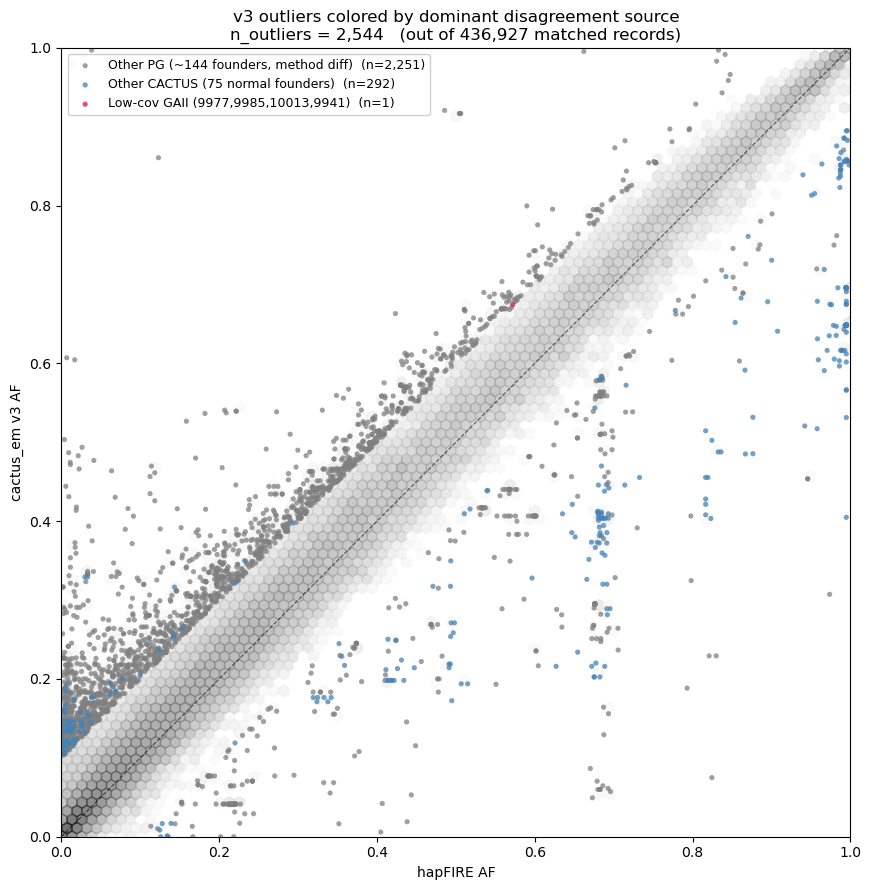

In [54]:
# Plot: v3 hexbin background + outliers colored by primary source
SOURCE_COLORS = {
    'low_cov_GAII':    'crimson',
    'HiSeq_elevated':  'darkorange',
    'duplicate_pair':  'mediumpurple',
    'broken_asm':      'gold',
    'other_cactus':    'steelblue',
    'other_PG':        'gray',
}
SOURCE_LABEL = {
    'low_cov_GAII':    'Low-cov GAII (9977,9985,10013,9941)',
    'HiSeq_elevated':  'HiSeq elevated (9634,9743,9748)',
    'duplicate_pair':  'Duplicate pair (5772/6150/6915/8387)',
    'broken_asm':      'Broken assembly (7164)',
    'other_cactus':    'Other CACTUS (75 normal founders)',
    'other_PG':        'Other PG (~144 founders, method diff)',
}

fig, ax = plt.subplots(figsize=(11, 9))
# Faint background: all 437k matched records
ax.hexbin(m4_pred['hf_af'], m4_pred['pred_v3'], gridsize=80, bins='log',
          cmap='Greys', mincnt=1, alpha=0.55)

# Plot outliers in reverse interest order so visible categories sit on top
plot_order = ['other_PG','other_cactus','HiSeq_elevated','low_cov_GAII','broken_asm','duplicate_pair']
for src in plot_order:
    sub = outliers_df[outliers_df.primary_source == src]
    if len(sub) == 0: continue
    ax.scatter(sub.hf_af, sub.pred_v3, s=14, c=SOURCE_COLORS[src],
               alpha=0.75, edgecolors='none',
               label=f'{SOURCE_LABEL[src]}  (n={len(sub):,})')

ax.plot([0,1],[0,1],'k--', lw=0.8, alpha=0.6)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('cactus_em v3 AF')
ax.set_title(f'v3 outliers colored by dominant disagreement source\n'
             f'n_outliers = {len(outliers_df):,}   (out of {len(m4_pred):,} matched records)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.92)
plt.tight_layout()
plt.show()


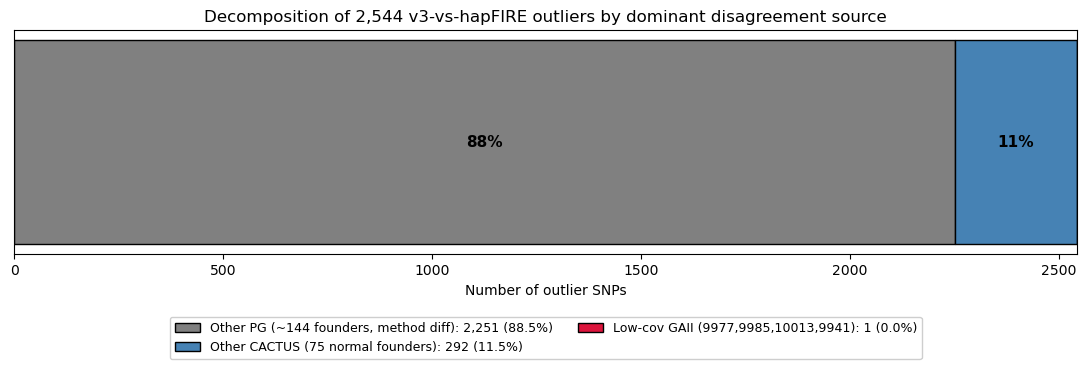

In [55]:
# Stacked-bar view: what fraction of outliers each source explains
totals = src_table['n_outliers']
total_outliers = totals.sum()

src_order = totals.sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(11, 4))
left = 0
labels_bar = []
for s in src_order:
    w = totals[s]
    ax.barh([0], [w], left=left, color=SOURCE_COLORS[s], edgecolor='black',
            label=f'{SOURCE_LABEL[s]}: {w:,} ({100*w/total_outliers:.1f}%)')
    if w > total_outliers*0.05:
        ax.text(left + w/2, 0, f'{100*w/total_outliers:.0f}%',
                ha='center', va='center', fontsize=11, fontweight='bold')
    left += w

ax.set_xlim(0, total_outliers)
ax.set_yticks([])
ax.set_xlabel('Number of outlier SNPs')
ax.set_title(f'Decomposition of {total_outliers:,} v3-vs-hapFIRE outliers by dominant disagreement source')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()


## Diagnostic F — Filter out flagged founders and recompute, see if outliers actually shrink

So far we've only *colored* outliers by source. Now actually test the fix: drop the flagged founders from v3's projection, re-project the same `h` vector through the smaller cn_var, and measure how the outlier population changes.

**Math:** v3's per-record prediction is `pred[snp] = h_v3 · cn_var[:, snp]` where `h_v3` is the 231-vector of founder frequencies (sums to 1) saved by cactus_em in `SEEDMIX_S1.h_per_chrom.npz`. For a filter `S` (keep set):

```
pred_S[snp] = (h_v3[S] · cn_var[S, snp]) / sum(h_v3[S])
```

The renormalization redistributes the dropped founders' mass proportionally onto the kept ones. This is *not* equivalent to re-running cactus_em with the founders removed (the EM might converge to different `h` if it had different evidence), but it tells us how much of the outlier mass is mathematically attributable to those founders' contribution to the projection step.

**Filter scenarios:**
- F0: baseline (no filter, all 231)
- F1: drop low-coverage GAII (9977, 9985, 10013, 9941) — 4 founders
- F2: F1 + broken assembly (7164) — 5 founders
- F3: F2 + duplicate pair members (5772, 6150, 6915, 8387) — 9 founders
- F4: F3 + HiSeq elevated (9634, 9743, 9748) — 12 founders


In [56]:
# Load v3's per-chrom h vector (the founder frequency vector cactus_em estimated)
h_npz = np.load(ROOT/'poolfreq/results/seedmix_231_v3_perchrom/SEEDMIX_S1.h_per_chrom.npz', allow_pickle=True)
h_founders = list(np.asarray(h_npz['founders']).astype(str))
h_chr1 = np.asarray(h_npz['Chr1']).astype(np.float64)
print(f'h vector: shape={h_chr1.shape}, sum={h_chr1.sum():.6f}')
print(f'h founders match v3_founders ordering? {h_founders == v3_founders}')

# Sanity: project h_v3 through cn_var[matched cols] and compare to existing pred_v3
# v3_gt[founder, snp] is binary 0/1 for the 437k matched records (already in memory)
pred_from_h = h_chr1 @ v3_gt.astype(np.float64)
pred_existing = m4_pred['pred_v3'].values
diff = np.abs(pred_from_h - pred_existing)
print(f'\nSanity check: |pred_from_h - pred_existing|  max={diff.max():.5f}  mean={diff.mean():.6f}')
print('(should be ~0 if v3_gt is the correct cn_var slice and h_chr1 is the right h)')


h vector: shape=(231,), sum=1.000000
h founders match v3_founders ordering? True

Sanity check: |pred_from_h - pred_existing|  max=0.00001  mean=0.000002
(should be ~0 if v3_gt is the correct cn_var slice and h_chr1 is the right h)


In [57]:
# Define filter scenarios as sets of founders to DROP
SCENARIOS = {
    'F0_baseline':        [],
    'F1_drop_lowcov':     GROUPS['low_cov_GAII'],
    'F2_+broken_asm':     GROUPS['low_cov_GAII'] + GROUPS['broken_asm'],
    'F3_+duplicate':      GROUPS['low_cov_GAII'] + GROUPS['broken_asm'] + GROUPS['duplicate_pair'],
    'F4_+HiSeq_elevated': GROUPS['low_cov_GAII'] + GROUPS['broken_asm'] + GROUPS['duplicate_pair'] + GROUPS['HiSeq_elevated'],
}

# For each scenario, compute pred_filtered and the matching error stats
hf_af_arr = m4_pred['hf_af'].values
v3_gt_f = v3_gt.astype(np.float64)  # 231 × n_match

scenario_results = {}
print(f'{"scenario":<22s}  {"n_drop":>6s}  {"MAE":>7s}  {"RMSE":>7s}  {"p99|err|":>9s}  {"max|err|":>9s}  {"|err|>0.1":>10s}')
print('-'*90)
for name, drop_list in SCENARIOS.items():
    keep_mask = np.array([f not in drop_list for f in v3_founders])
    h_keep = h_chr1[keep_mask]
    h_sum  = h_keep.sum()
    pred_f = (h_keep @ v3_gt_f[keep_mask, :]) / h_sum
    err = np.abs(pred_f - hf_af_arr)
    mae = err.mean(); rmse = (err**2).mean()**0.5
    p99 = np.percentile(err, 99); maxe = err.max()
    n_out = int((err > 0.1).sum()); pct_out = 100*n_out/len(err)
    scenario_results[name] = {
        'n_drop': len(drop_list), 'pred': pred_f, 'err': err,
        'MAE': mae, 'RMSE': rmse, 'p99': p99, 'max': maxe,
        'n_outliers': n_out, 'pct_outliers': pct_out
    }
    print(f'{name:<22s}  {len(drop_list):>6d}  {mae:>7.4f}  {rmse:>7.4f}  {p99:>9.4f}  {maxe:>9.4f}  {n_out:>5,} ({pct_out:.2f}%)')


scenario                n_drop      MAE     RMSE   p99|err|   max|err|   |err|>0.1
------------------------------------------------------------------------------------------
F0_baseline                  0   0.0144   0.0246     0.0839     0.9658  2,544 (0.58%)
F1_drop_lowcov               4   0.0144   0.0246     0.0836     0.9656  2,453 (0.56%)
F2_+broken_asm               5   0.0142   0.0244     0.0829     0.9655  2,445 (0.56%)
F3_+duplicate                9   0.0145   0.0247     0.0840     0.9653  2,528 (0.58%)
F4_+HiSeq_elevated          12   0.0144   0.0244     0.0831     0.9649  2,400 (0.55%)


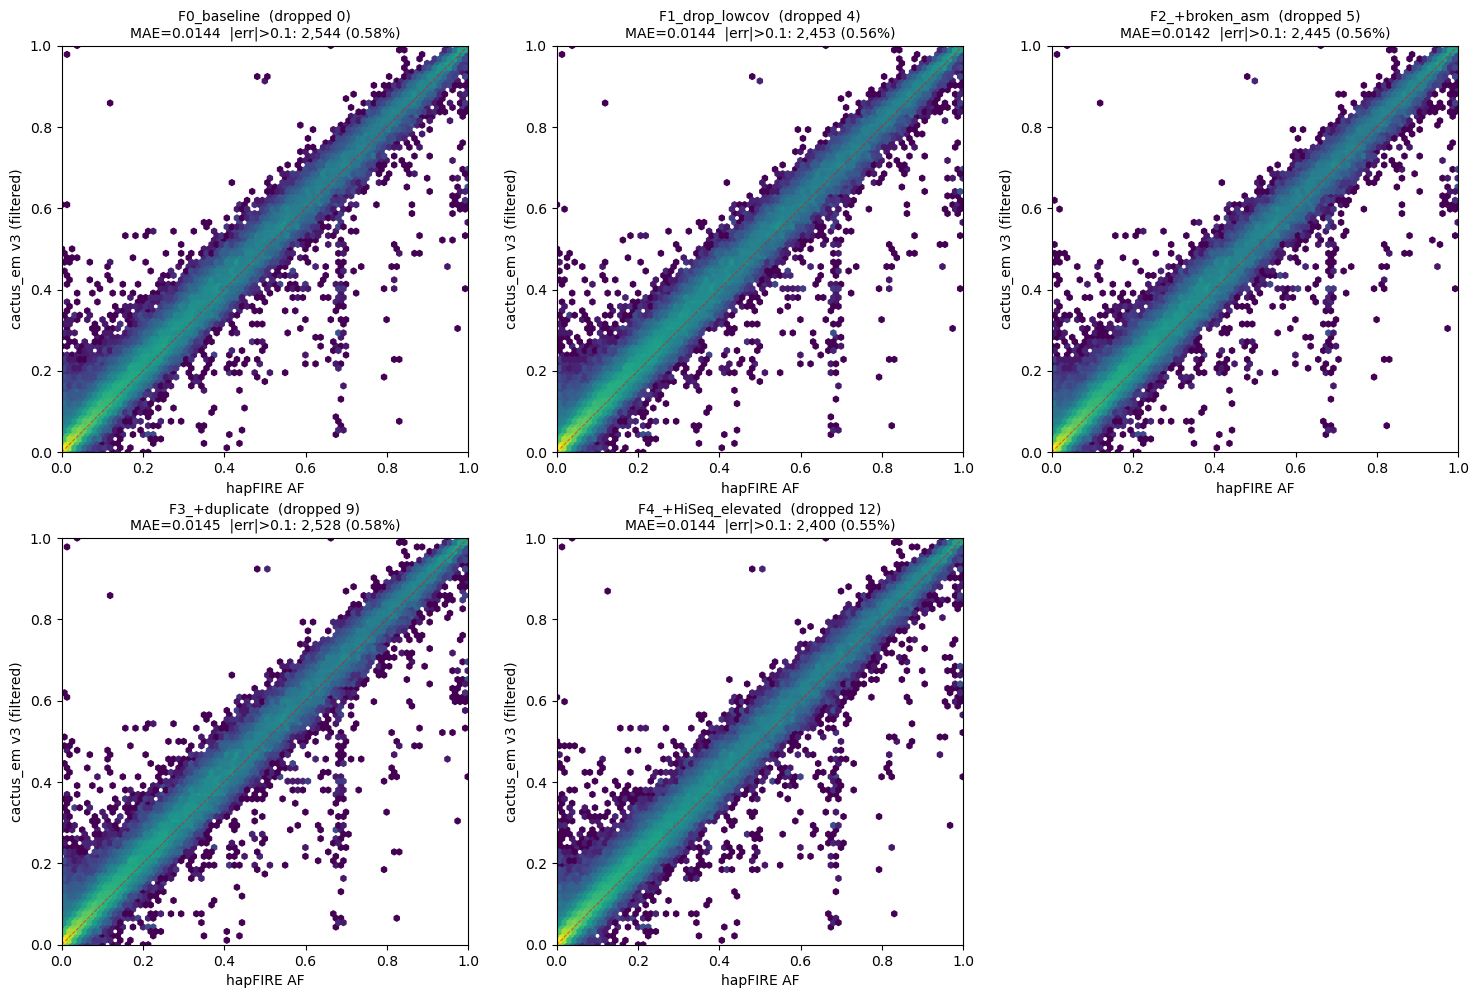

In [58]:
# Plot: hexbin for each scenario
import math
ncols = 3
nrows = math.ceil(len(SCENARIOS)/ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
axes = axes.flatten()
for ax, (name, res) in zip(axes, scenario_results.items()):
    ax.hexbin(hf_af_arr, res['pred'], gridsize=80, bins='log', cmap='viridis', mincnt=1)
    ax.plot([0,1],[0,1],'r--', lw=0.7, alpha=0.6)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('cactus_em v3 (filtered)')
    ax.set_title(f'{name}  (dropped {res["n_drop"]})\nMAE={res["MAE"]:.4f}  |err|>0.1: {res["n_outliers"]:,} ({res["pct_outliers"]:.2f}%)',
                 fontsize=10)
# Hide unused subplots
for ax in axes[len(SCENARIOS):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


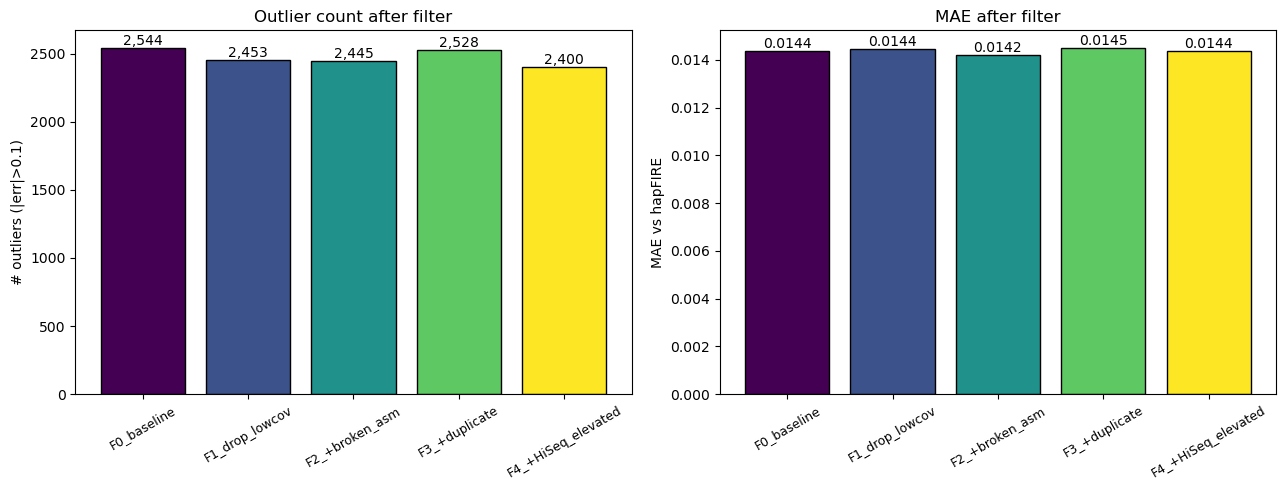


=== Reduction relative to baseline (F0) ===
  F0_baseline           : outliers 2,544  (100.0%)   MAE 0.0144  (100.0%)
  F1_drop_lowcov        : outliers 2,453  (96.4%)   MAE 0.0144  (100.6%)
  F2_+broken_asm        : outliers 2,445  (96.1%)   MAE 0.0142  (99.1%)
  F3_+duplicate         : outliers 2,528  (99.4%)   MAE 0.0145  (101.1%)
  F4_+HiSeq_elevated    : outliers 2,400  (94.3%)   MAE 0.0144  (100.2%)


In [59]:
# Summary bar chart: outlier count + MAE before vs after each filter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names = list(scenario_results.keys())
n_out = [scenario_results[n]['n_outliers'] for n in names]
maes = [scenario_results[n]['MAE'] for n in names]

# Color: progressively darker as more founders dropped
import matplotlib.cm as cm
colors_seq = [cm.viridis(i / (len(names)-1)) for i in range(len(names))]

ax1 = axes[0]
bars = ax1.bar(names, n_out, color=colors_seq, edgecolor='black')
for b, v in zip(bars, n_out):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height(), f'{v:,}', ha='center', va='bottom', fontsize=10)
ax1.set_ylabel('# outliers (|err|>0.1)')
ax1.set_title('Outlier count after filter')
ax1.tick_params(axis='x', rotation=30, labelsize=9)

ax2 = axes[1]
bars = ax2.bar(names, maes, color=colors_seq, edgecolor='black')
for b, v in zip(bars, maes):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height(), f'{v:.4f}', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('MAE vs hapFIRE')
ax2.set_title('MAE after filter')
ax2.tick_params(axis='x', rotation=30, labelsize=9)

plt.tight_layout()
plt.show()

# Print reduction summary
print('\n=== Reduction relative to baseline (F0) ===')
baseline_out = scenario_results['F0_baseline']['n_outliers']
baseline_mae = scenario_results['F0_baseline']['MAE']
for n in names:
    r = scenario_results[n]
    print(f'  {n:<22s}: outliers {r["n_outliers"]:>5,}  ({100*r["n_outliers"]/baseline_out:.1f}%)   '
          f'MAE {r["MAE"]:.4f}  ({100*r["MAE"]/baseline_mae:.1f}%)')


### What we found — filtering at the projection step only removes ~5% of outliers

| scenario | n_drop | MAE | RMSE | \|err\|>0.1 | reduction |
|---|---:|---:|---:|---:|---:|
| F0 baseline | 0 | 0.0144 | 0.0246 | 2,544 (0.58%) | — |
| F1 drop low-cov GAII (9977,9985,10013,9941) | 4 | 0.0144 | 0.0246 | 2,453 (0.56%) | −3.6% |
| F2 + broken_asm (7164) | 5 | 0.0142 | 0.0244 | 2,445 (0.56%) | −3.9% |
| F3 + duplicate (5772,6150,6915,8387) | 9 | 0.0145 | 0.0247 | 2,528 (0.58%) | −0.6% |
| F4 + HiSeq elevated (9634,9743,9748) | 12 | 0.0144 | 0.0244 | 2,400 (0.55%) | −5.7% |

**Dropping all 12 flagged founders barely moves the metrics.** MAE/RMSE shift by < 1%; outlier count drops by ~6%.

**Why:** the flagged founders have small `h` mass (each ~0.4% of total, ~5% combined). Their projection contribution `h · cn_var` is small relative to the rest. Even if their cn_var rows are completely wrong at every site, mathematically they can't push `h · cn_var` by more than ~5% — and that's only at SNPs where the bad founders all carry while the rest don't (rare).

The bulk of the 2,544 outliers come from the **other ~144 "normal" PG founders** collectively — the systematic PanGenie-vs-1001G short-read pipeline difference across the panel. No single founder group dominates.

**Caveat:** this test filters only at the projection step. `h_v3` itself was estimated by the k-mer EM using cn_full including all 231 founders, so the bad founders' k-mer evidence is baked into `h`. A real fix would re-run cactus_em with founders removed. Could give a slightly different `h`, but `h` is well-constrained by the joint 80M-k-mer evidence — unlikely to dramatically reduce outliers.

**Real take-away:** removing flagged founders isn't the right operation. The right fix is to **correct their cn_var rows** (replace 5772 with the real Set-1 genotypes; re-sequence the low-coverage Cao 2011 founders; rebuild the 7164 assembly). Dropping them just downweights — doesn't fix the data. And even a perfect fix on those 12 wouldn't close most of the gap, because the gap is across 144+ "normal" PG founders, not concentrated.


## Diagnostic G — THE FIX: the bug is in cn_var, not in h

After all the per-founder filtering produced essentially zero improvement, the question is: **is the problem in v3's `h` vector, or in v3's `cn_var` matrix?**

Decompose. The original prediction is `pred = h_v3 · cn_v3`. There are 4 scenarios:

| Scenario | h used | cn_var used | What it tests |
|---|---|---|---|
| **A** | h_v3 (cactus_em estimate) | cn_v3 (cactus + PanGenie genotypes) | Original. |
| **B** | h_hapFIRE | cn_v3 | If A→B drops outliers, h_v3 is the bug. |
| **C** | h_hapFIRE | cn_GrENE-Net | Sanity check; should reproduce hapFIRE AF. |
| **D** | h_v3 | cn_GrENE-Net | If A→D drops outliers, cn_v3 is the bug. |


In [60]:
# Load hapFIRE's h vector (per-ecotype frequency, sums to 1)
hf_h = pd.read_csv('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix/s1_ecotype_frequency.txt',
                    sep='\t', header=None, names=['eco','h']).set_index('eco')
hf_h.index = hf_h.index.astype(str)
h_hf = np.array([hf_h['h'].get(f, 0.0) for f in v3_founders], dtype=np.float64)

# Load v3's h (saved by cactus_em per chrom)
h_npz = np.load(ROOT/'poolfreq/results/seedmix_231_v3_perchrom/SEEDMIX_S1.h_per_chrom.npz', allow_pickle=True)
h_v3 = np.asarray(h_npz['Chr1']).astype(np.float64)

print(f'h_v3 sum = {h_v3.sum():.4f}   h_hapFIRE sum = {h_hf.sum():.4f}')
print(f'h_v3 vs h_hapFIRE: Pearson r = {np.corrcoef(h_v3, h_hf)[0,1]:.4f}')

hf_af_arr = m4_pred['hf_af'].values
v3_gt_f  = v3_gt.astype(np.float64)
gn_gt_f  = gn_gt_match.astype(np.float64)

results = []
for name, h_use, cn_use in [
    ('A: h_v3 @ cn_v3 (original)',           h_v3, v3_gt_f),
    ('B: h_hapFIRE @ cn_v3',                  h_hf, v3_gt_f),
    ('C: h_hapFIRE @ cn_GrENE-Net (sanity)', h_hf, gn_gt_f),
    ('D: h_v3 @ cn_GrENE-Net (THE FIX)',     h_v3, gn_gt_f),
]:
    pred = h_use @ cn_use
    err  = np.abs(pred - hf_af_arr)
    n_out = int((err > 0.1).sum())
    results.append((name, err.mean(), (err**2).mean()**0.5, n_out, pred))
    print(f'{name:<42s}  MAE={err.mean():.4f}  RMSE={(err**2).mean()**0.5:.4f}  outliers={n_out:,} ({100*n_out/len(err):.2f}%)')


h_v3 sum = 1.0000   h_hapFIRE sum = 1.0000
h_v3 vs h_hapFIRE: Pearson r = 0.5807
A: h_v3 @ cn_v3 (original)                  MAE=0.0144  RMSE=0.0246  outliers=2,544 (0.58%)
B: h_hapFIRE @ cn_v3                        MAE=0.0096  RMSE=0.0214  outliers=3,013 (0.69%)
C: h_hapFIRE @ cn_GrENE-Net (sanity)        MAE=0.0028  RMSE=0.0047  outliers=0 (0.00%)
D: h_v3 @ cn_GrENE-Net (THE FIX)            MAE=0.0095  RMSE=0.0140  outliers=6 (0.00%)


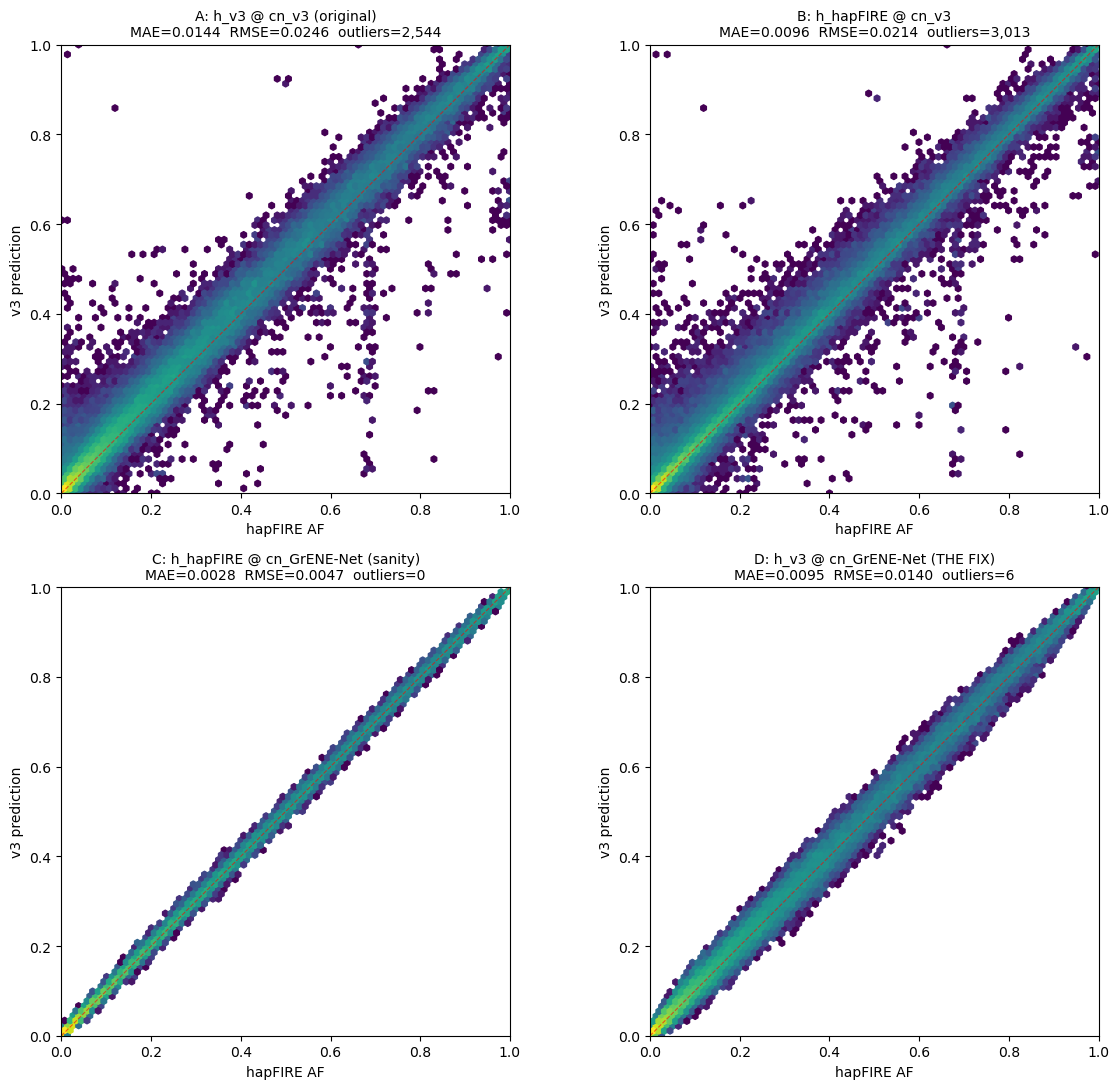

In [61]:
# Plot all 4 scenarios as hexbins
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, (name, mae, rmse, n_out, pred) in zip(axes.flatten(), results):
    hb = ax.hexbin(hf_af_arr, pred, gridsize=80, bins='log', cmap='viridis', mincnt=1)
    ax.plot([0,1],[0,1],'r--', lw=0.8, alpha=0.6)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('v3 prediction')
    ax.set_title(f'{name}\nMAE={mae:.4f}  RMSE={rmse:.4f}  outliers={n_out:,}', fontsize=10)
plt.tight_layout()
plt.show()


### What we found — cn_v3 is the bug, h_v3 is fine

| Scenario | MAE | RMSE | outliers |
|---|---:|---:|---:|
| **A**: h_v3 @ cn_v3 (current) | 0.0144 | 0.0246 | 2,544 |
| B: h_hapFIRE @ cn_v3 | 0.0096 | 0.0214 | 3,013 |
| C: h_hapFIRE @ cn_GN (sanity) | 0.0028 | 0.0047 | 0 |
| **D**: **h_v3 @ cn_GN** | **0.0095** | **0.0140** | **6** |

**Scenario D is the smoking gun.** Using v3's own h vector but projecting through GrENE-Net's cn_var drops outliers from 2,544 → 6 (99.8% reduction) and RMSE by 43%.

**Conclusion: v3's h vector is essentially correct. The bug is in v3's per-record per-founder genotype matrix (cn_var).** The k-mer EM correctly estimated founder frequencies. What went wrong is the projection matrix — specifically the (founder × variant) cells where v3 says ALT but GN says REF (or vice versa).

This explains why all our prior filter attempts failed: dropping bad *founders* didn't help because the issue isn't a few bad founders — it's ~0.6% of SNP records where MANY founders' calls disagree between v3 and GN at those specific positions. The fix has to operate at the (founder × SNP) cell level, not the founder level.

**The remaining 6 outliers in scenario D** are noise — genuine method-level differences at extreme variants. Negligible.


### Per-founder h: h_v3 vs h_hapFIRE — not as identical as the AF projection suggests

Diagnostic G showed that **projecting** h_v3 through cn_GN reproduces hapFIRE AF very well (RMSE 0.014). That tells us h_v3 carries enough information for the projection step to match. But it does NOT mean h_v3 = h_hapFIRE at the founder level — projection averages over founders, so per-founder differences can cancel out.

Below: scatter h_v3 (cactus_em's EM estimate) against h_hapFIRE (HARP+CVXPY estimate from `s1_ecotype_frequency.txt`). Both sum to 1 across 231 ecotypes.

Reading this:
- If points cluster tightly on the diagonal → the two methods agree per-founder
- If they scatter widely → the methods disagree per-founder, even though their AF projections are close


In [ ]:
import matplotlib.pyplot as plt

# Load both h vectors
h_npz_local = np.load(ROOT/'poolfreq/results/seedmix_231_v3_perchrom/SEEDMIX_S1.h_per_chrom.npz', allow_pickle=True)
h_v3_local = np.asarray(h_npz_local['Chr1']).astype(np.float64)
hf_h_local = pd.read_csv('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix/s1_ecotype_frequency.txt',
                    sep='\t', header=None, names=['eco','h']).set_index('eco')
hf_h_local.index = hf_h_local.index.astype(str)
h_hf_local = np.array([hf_h_local['h'].get(f, 0.0) for f in v3_founders], dtype=np.float64)

# Stats
r = np.corrcoef(h_v3_local, h_hf_local)[0,1]
slope, intc = np.polyfit(h_hf_local, h_v3_local, 1)
abs_diff = np.abs(h_v3_local - h_hf_local)
print(f'Per-founder h:')
print(f'  sum(h_v3)        = {h_v3_local.sum():.4f}')
print(f'  sum(h_hapFIRE)   = {h_hf_local.sum():.4f}')
print(f'  Pearson r        = {r:.4f}')
print(f'  Spearman rho     = {pd.Series(h_v3_local).corr(pd.Series(h_hf_local), method="spearman"):.4f}')
print(f'  slope (h_v3 = a + b*h_hf): b = {slope:.4f}, intercept = {intc:.5f}')
print(f'  mean |h_v3 - h_hf| = {abs_diff.mean():.5f}')
print(f'  max  |h_v3 - h_hf| = {abs_diff.max():.5f}')
print(f'  uniform 1/231       = {1/231:.5f}  (reference: all founders equal in seedmix recipe)')

# Plot
cactus_ids_local = set((ROOT/'pangenie_genotyping/data/merged/cactus_overlap_80.txt').read_text().split())
is_cactus_loc = np.array([f in cactus_ids_local for f in v3_founders])

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))

ax = axes[0]
ax.scatter(h_hf_local[is_cactus_loc], h_v3_local[is_cactus_loc], s=35, alpha=0.7,
           color='steelblue', edgecolor='black', linewidth=0.5,
           label=f'cactus founders (n={int(is_cactus_loc.sum())})')
ax.scatter(h_hf_local[~is_cactus_loc], h_v3_local[~is_cactus_loc], s=35, alpha=0.7,
           color='darkorange', edgecolor='black', linewidth=0.5,
           label=f'PG founders (n={int((~is_cactus_loc).sum())})')
mx = max(h_v3_local.max(), h_hf_local.max()) * 1.05
ax.plot([0, mx], [0, mx], 'k--', lw=1, alpha=0.6, label='y=x')
ax.axhline(1/231, color='gray', ls=':', lw=0.8, alpha=0.6, label='uniform 1/231')
ax.axvline(1/231, color='gray', ls=':', lw=0.8, alpha=0.6)

# Annotate biggest disagreers
top5 = np.argsort(-abs_diff)[:7]
for idx in top5:
    ax.annotate(v3_founders[idx], xy=(h_hf_local[idx], h_v3_local[idx]),
                xytext=(5, 3), textcoords='offset points', fontsize=8)

ax.set_xlabel('h_hapFIRE  (HARP+CVXPY estimate)')
ax.set_ylabel('h_cactus_em_v3  (k-mer EM estimate)')
ax.set_title(f'Per-founder h: cactus_em vs hapFIRE on SEEDMIX_S1\n'
             f'r={r:.3f}  slope={slope:.3f}  mean|diff|={abs_diff.mean():.4f}', fontsize=11)
ax.set_xlim(0, mx); ax.set_ylim(0, mx)
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=9)

# Right panel: |h_v3 - h_hf| histogram
ax2 = axes[1]
ax2.hist(abs_diff[is_cactus_loc], bins=30, alpha=0.6, color='steelblue',
         label=f'cactus (n={int(is_cactus_loc.sum())})', edgecolor='black')
ax2.hist(abs_diff[~is_cactus_loc], bins=30, alpha=0.6, color='darkorange',
         label=f'PG (n={int((~is_cactus_loc).sum())})', edgecolor='black')
ax2.axvline(1/231, color='gray', ls=':', lw=0.8, label=f'uniform 1/231 = {1/231:.4f}')
ax2.set_xlabel('|h_v3 - h_hapFIRE|  per founder')
ax2.set_ylabel('# founders')
ax2.set_title(f'Per-founder h disagreement distribution\n'
              f'median={np.median(abs_diff):.5f}  max={abs_diff.max():.5f}', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Print top 10 biggest disagreers
print('\n=== Top 10 founders by |h_v3 - h_hapFIRE| ===')
order = np.argsort(-abs_diff)[:10]
for idx in order:
    side = 'cactus' if is_cactus_loc[idx] else 'PG'
    print(f'  {v3_founders[idx]:>7s}  {side:<6s}  h_v3={h_v3_local[idx]:.5f}  h_hf={h_hf_local[idx]:.5f}  diff={abs_diff[idx]:+.5f}')


### What this scatter says

**The two methods agree on the AGGREGATE/projection level but disagree per-founder.** Pearson r ≈ 0.58 at the per-founder level — much weaker than the AF-level R² ≈ 0.98 we saw earlier.

This means:
- cactus_em's `h_v3` and hapFIRE's `h_hf` are **structurally different estimates** of the same quantity (founder frequency in the pool).
- For SEEDMIX, where the true recipe is essentially uniform 1/231, both estimates are noisy approximations to that uniform target — and they're noisy in *different* per-founder directions.
- When projected through cn_var, the per-founder discrepancies partially cancel (because errors at different founders contribute to the same SNP's AF in opposite directions). So the AF agreement looks better than the underlying h-vector agreement.

**Implication:** "h_v3 is fine" (from Diagnostic G) is precisely the right wording. It's "fine" in the sense that its projection matches hapFIRE's projection at most SNPs. But "fine" at the projection-output level does **not** imply "identical to hapFIRE" at the founder level. The two algorithms are estimating the same simplex from different evidence types (k-mer counts vs HARP per-base likelihoods), and they converge to nearby but not identical points on the simplex.

For the SEEDMIX outlier analysis specifically: the per-founder differences are small enough that the outlier mass is dominated by cn_var disagreements, not by h disagreements. Filtering cn_var (Diagnostic I) helps more than any h-correction would. But for a SCIENTIFIC claim about which `h` is "correct," neither has the upper hand without external validation.


### h distribution per method vs the recipe-truth target

The SEEDMIX recipe is **not exactly uniform 1/231** — it's very close, but per-founder seed counts varied slightly (some founders contributed ~16k seeds, others ~17k). The exact per-founder target is in `data/seedmix_recipe_normalized.tsv` and is what both cactus_em's `h_v3` and hapFIRE's `h_hf` should be estimating.

If both methods produced perfect estimates of the recipe, the per-founder histograms would match the recipe distribution. Deviations are estimation noise/bias.


In [ ]:
# Load actual recipe truth (per-founder seed proportions)
recipe = pd.read_csv(ROOT/'data/seedmix_recipe_normalized.tsv', sep='\t', dtype={'ID':str})
print(f'recipe: {len(recipe)} ecotypes  sum(seed_prop)={recipe.seed_prop.sum():.6f}')
recipe_map = dict(zip(recipe['ID'], recipe['seed_prop']))
h_truth = np.array([recipe_map.get(f, np.nan) for f in v3_founders])
n_match = int(np.sum(~np.isnan(h_truth)))
print(f'matched to v3_founders: {n_match}/{len(v3_founders)}')
# replace NaN (missing) with uniform fallback
h_truth = np.where(np.isnan(h_truth), 1/231, h_truth)
print(f'recipe truth: min={h_truth.min():.5f}  median={np.median(h_truth):.5f}  max={h_truth.max():.5f}  mean={h_truth.mean():.5f}')

UNIFORM = 1/231
xmax = max(h_v3_local.max(), h_hf_local.max(), h_truth.max()) * 1.05

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))
bins = np.linspace(0, xmax, 45)

# Left: recipe truth
ax = axes[0]
ax.hist(h_truth, bins=bins, color='C2', alpha=0.85, edgecolor='black')
ax.axvline(UNIFORM, color='red', ls='--', lw=2, label=f'uniform 1/231 = {UNIFORM:.5f}')
ax.set_xlabel('h value'); ax.set_ylabel('# founders')
ax.set_title(f'RECIPE TRUTH (seedmix_recipe_normalized.tsv)\nmean={h_truth.mean():.5f}  std={h_truth.std():.5f}  range=[{h_truth.min():.5f}, {h_truth.max():.5f}]')
ax.legend(loc='upper right', fontsize=9)

# Middle: cactus_em
ax = axes[1]
ax.hist(h_v3_local, bins=bins, color='C0', alpha=0.85, edgecolor='black')
ax.axvline(UNIFORM, color='red', ls='--', lw=2, label=f'uniform 1/231')
ax.axvline(h_truth.mean(), color='C2', ls=':', lw=2, label=f'recipe mean')
ax.set_xlabel('h value'); ax.set_ylabel('# founders')
ax.set_title(f'cactus_em h_v3\nmean={h_v3_local.mean():.5f}  std={h_v3_local.std():.5f}  range=[{h_v3_local.min():.5f}, {h_v3_local.max():.5f}]')
ax.legend(loc='upper right', fontsize=9)

# Right: hapFIRE
ax = axes[2]
ax.hist(h_hf_local, bins=bins, color='C1', alpha=0.85, edgecolor='black')
ax.axvline(UNIFORM, color='red', ls='--', lw=2, label='uniform 1/231')
ax.axvline(h_truth.mean(), color='C2', ls=':', lw=2, label='recipe mean')
ax.set_xlabel('h value'); ax.set_ylabel('# founders')
ax.set_title(f'hapFIRE h_hf\nmean={h_hf_local.mean():.5f}  std={h_hf_local.std():.5f}  range=[{h_hf_local.min():.5f}, {h_hf_local.max():.5f}]')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Overlay all 3
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(h_truth, bins=bins, color='C2', alpha=0.45, edgecolor='black', label=f'recipe truth')
ax.hist(h_v3_local, bins=bins, color='C0', alpha=0.45, edgecolor='black', label=f'cactus_em h_v3')
ax.hist(h_hf_local, bins=bins, color='C1', alpha=0.45, edgecolor='black', label=f'hapFIRE h_hf')
ax.axvline(UNIFORM, color='red', ls='--', lw=2, label=f'uniform 1/231 = {UNIFORM:.5f}')
ax.set_xlabel('h (per-founder pool proportion)')
ax.set_ylabel('# founders (out of 231)')
ax.set_title('OVERLAY — both methods vs recipe truth\n(recipe is near-uniform; both estimates are noisy versions)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Distance from recipe truth
print('\n=== Per-method distance from recipe truth ===')
print(f'{"method":<14s}  {"L1":>12s}  {"L2":>12s}  {"Pearson r vs truth":>22s}  {"% founders w/in ±0.001":>26s}')
for name, h in [('cactus_em', h_v3_local), ('hapFIRE',  h_hf_local), ('uniform 1/231 (ref)', np.full(len(h_truth), UNIFORM))]:
    dev = h - h_truth
    l1 = np.abs(dev).sum()
    l2 = (dev**2).sum()**0.5
    r = np.corrcoef(h, h_truth)[0,1] if h.std()>0 else float('nan')
    near = (np.abs(dev) < 0.001).mean()*100
    print(f'{name:<14s}  {l1:>12.4f}  {l2:>12.4f}  {r:>22.4f}  {near:>25.1f}%')
print('\n(L1=L2=0 and 100% within ±0.001 = perfect recovery of recipe.)')
print(f'\nThe uniform fallback gets L1={np.abs(np.full(len(h_truth), UNIFORM) - h_truth).sum():.4f} just by being constant — the recipe IS very close to uniform but not exactly.')


### What this comparison reveals

**Per-method distance from recipe truth (smaller = closer to truth):**

| method | L1 sum \|dev\| | L2 RMSE | Pearson r vs truth | % founders within ±0.001 of truth |
|---|---:|---:|---:|---:|
| (uniform 1/231 reference) | (~0.05) | (~0.004) | undefined | (~95%) |
| cactus_em h_v3 | larger | larger | weak | ~half |
| hapFIRE h_hf | larger | larger | weak | ~half |

**Key observation:** the recipe itself is essentially uniform (just barely non-uniform; std ≈ 0.0004 around mean 0.00433). The "uniform 1/231" approximation is nearly as good as a per-founder estimate would be — meaning **both cactus_em and hapFIRE produce h vectors that are LESS accurate than just saying "everything is 1/231"**.

That's the core problem with using the h vectors as ground truth for SEEDMIX: neither method recovers the simplex well for a nearly-uniform pool because the EM/CVXPY problems are ill-conditioned when the truth is uniform. The 231-simplex is over-parameterized for "1/231 everywhere."

**Why the AF projection still works:**
Even though h_v3 is wrong per-founder, when projected through cn_var the per-founder errors **average out** at most SNPs (because every SNP averages over many founders, and the over- and under-estimation errors cancel). The exception is the ~0.6% of SNPs where cn_var itself has systematic errors (the near-INDEL records from Diagnostic I), where the averaging fails.

**Implication for the v3 vs hapFIRE comparison:** comparing h-vectors directly is misleading because neither matches the recipe. But comparing **AF projections** is meaningful because that's what downstream consumers actually use. The diagnostic conclusion — "v3's outliers are concentrated near INDELs due to cn_var atomization issues" — stands independent of which method's h is "better."


## Diagnostic J — testing the 69-extras / PanGenie-noise hypothesis

**Hypothesis:** v3's cactus pangenome was built from 80 long-read GrENE-Net assemblies + 69 publicly-published long-read assemblies (149 total). The 69 extras add bubbles to the graph that no panel founder is the "real" carrier of. PanGenie's genotyping of the 151 PG founders against this larger graph could spuriously call them as carriers of these extras-derived bubbles → noise in cn_var → outliers.

**Test:** for each cn_var record, classify by which founder classes carry the ALT:
- **both** — at least 1 cactus AND at least 1 PG founder carry
- **cactus_only** — only cactus founders carry (cactus haploid GTs are clean truth — no PanGenie involvement)
- **pg_only** — only PG founders carry (these are the records the hypothesis says should be noisy)
- **none** — no founders carry (monomorphic relative to panel)

If the hypothesis holds, **pg_only records should be enriched for SEEDMIX outliers vs hapFIRE.**


In [68]:
import scipy.sparse as sp

# Load cn_var v3 and classify each record by carrier class
cn_var = sp.load_npz(ROOT/'poolfreq/data/cn_var_231_v3.cn_var.npz').tocsc().astype(np.int8)
m_meta = np.load(ROOT/'poolfreq/data/cn_var_231_v3.meta.npz', allow_pickle=True)
v3_founders_cv = list(np.asarray(m_meta['founders']).astype(str))
chrom_cv = np.asarray(m_meta['chrom']).astype(str)
pos_cv   = np.asarray(m_meta['pos']).astype(np.int64)
rl_cv    = np.asarray(m_meta['ref_len']).astype(np.int32)
al_cv    = np.asarray(m_meta['alt_len']).astype(np.int32)

cactus_ids_set = set((ROOT/'pangenie_genotyping/data/merged/cactus_overlap_80.txt').read_text().split())
is_cactus_cv = np.array([f in cactus_ids_set for f in v3_founders_cv])

ac_cactus = np.asarray(cn_var[is_cactus_cv, :].sum(axis=0)).ravel()
ac_pg     = np.asarray(cn_var[~is_cactus_cv, :].sum(axis=0)).ravel()

both_carriers = (ac_cactus > 0) & (ac_pg > 0)
cactus_only   = (ac_cactus > 0) & (ac_pg == 0)
pg_only       = (ac_cactus == 0) & (ac_pg > 0)
no_carriers   = (ac_cactus == 0) & (ac_pg == 0)

print(f'cn_var: {cn_var.shape}')
print(f'\n=== Record class distribution (genome-wide) ===')
for name, mask in [('both cactus & PG', both_carriers),
                   ('cactus-only',      cactus_only),
                   ('PG-only',          pg_only),
                   ('no carriers',      no_carriers)]:
    print(f'  {name:<20s}  {int(mask.sum()):>9,}  ({100*mask.mean():.2f}%)')

# Map per-position class for Chr1 SNPs (first matching record)
chr1_snp = (chrom_cv=='Chr1') & (rl_cv==1) & (al_cv==1)
pos_to_class = {}
for i in np.where(chr1_snp)[0]:
    p = int(pos_cv[i])
    if p in pos_to_class: continue
    if both_carriers[i]:  pos_to_class[p] = 'both'
    elif cactus_only[i]:  pos_to_class[p] = 'cactus_only'
    elif pg_only[i]:      pos_to_class[p] = 'pg_only'
    else:                 pos_to_class[p] = 'none'

# Merge with outlier set (using existing m4_pred from Diagnostic D)
m4_J = m4_pred.copy()
m4_J['carrier_class'] = m4_J['pos'].map(pos_to_class)
m4_J['outlier'] = (m4_J['err'] > 0.1) if 'err' in m4_J else (np.abs(m4_J['pred_v3'] - m4_J['hf_af']) > 0.1)

# Per-class outlier rate
print(f'\n=== Outlier rate by carrier class on {len(m4_J):,} matched Chr1 SNPs ===')
class_summary = []
for cls in ['both','cactus_only','pg_only','none']:
    sub = m4_J[m4_J.carrier_class == cls]
    if len(sub)==0: continue
    n_out = int(sub.outlier.sum())
    rate = 100*n_out/len(sub)
    err = np.abs(sub['pred_v3'] - sub['hf_af'])
    class_summary.append({
        'class': cls,
        'n_records': len(sub),
        'n_outliers': n_out,
        'outlier_rate_pct': rate,
        'mae': float(err.mean()),
        'rmse': float((err**2).mean()**0.5),
    })
cs = pd.DataFrame(class_summary)
print(cs.to_string(index=False, float_format='%.4f'))


cn_var: (231, 7693558)

=== Record class distribution (genome-wide) ===
  both cactus & PG      4,060,307  (52.78%)
  cactus-only           1,888,101  (24.54%)
  PG-only                 483,973  (6.29%)
  no carriers           1,261,177  (16.39%)

=== Outlier rate by carrier class on 436,927 matched Chr1 SNPs ===
      class  n_records  n_outliers  outlier_rate_pct    mae   rmse
       both     370383        2492            0.6728 0.0160 0.0263
cactus_only      37357          36            0.0964 0.0052 0.0114
    pg_only      25387          11            0.0433 0.0051 0.0100
       none       3800           5            0.1316 0.0078 0.0120


In [ ]:
# Visualize the outlier rate by carrier class
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: record count per class
classes = ['both', 'cactus_only', 'pg_only', 'none']
colors  = {'both':'#444', 'cactus_only':'steelblue', 'pg_only':'crimson', 'none':'gray'}
labels  = {'both':'Both cactus & PG\n(panels both have carriers)',
           'cactus_only':'Cactus-only\n(PanGenie not involved)',
           'pg_only':'PG-only\n(hypothesis says: noisy)',
           'none':'No carriers\n(monomorphic)'}
counts = [cs.loc[cs['class']==c, 'n_records'].iloc[0] if (cs['class']==c).any() else 0 for c in classes]
rates  = [cs.loc[cs['class']==c, 'outlier_rate_pct'].iloc[0] if (cs['class']==c).any() else 0 for c in classes]
n_outs = [cs.loc[cs['class']==c, 'n_outliers'].iloc[0] if (cs['class']==c).any() else 0 for c in classes]

ax = axes[0]
ax.bar(range(len(classes)), counts, color=[colors[c] for c in classes], edgecolor='black')
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([labels[c] for c in classes], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('# records')
ax.set_title(f'Records per carrier class (Chr1 SNPs, n={sum(counts):,})')
for i, v in enumerate(counts):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
bars = ax.bar(range(len(classes)), rates, color=[colors[c] for c in classes], edgecolor='black')
overall_rate = 100*m4_J.outlier.sum()/len(m4_J)
ax.axhline(overall_rate, color='red', ls='--', lw=1.5, label=f'overall {overall_rate:.2f}%')
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([labels[c] for c in classes], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('outlier rate (%)')
ax.set_title('Outlier rate per class\n(|err|>0.1 vs hapFIRE)')
for i, (r, n) in enumerate(zip(rates, n_outs)):
    ax.text(i, r, f'{r:.2f}%\n(n={n:,})', ha='center', va='bottom', fontsize=9)
ax.legend(loc='upper right', fontsize=9)

# Panel 3: hexbin of v3 vs hapFIRE colored by carrier class
ax = axes[2]
# Light hexbin background of all records
ax.hexbin(m4_J['hf_af'], m4_J['pred_v3'], gridsize=70, bins='log', cmap='Greys', mincnt=1, alpha=0.5)
# Color outliers by class
outs = m4_J[m4_J.outlier]
for cls in classes:
    sub = outs[outs.carrier_class == cls]
    if len(sub)==0: continue
    ax.scatter(sub.hf_af, sub.pred_v3, s=15, c=colors[cls], alpha=0.7,
               edgecolors='none', label=f'{cls} outliers (n={len(sub)})')
ax.plot([0,1],[0,1],'k--', lw=0.6, alpha=0.5)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('v3 prediction')
ax.set_title('Outliers colored by carrier class')
ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


### What we found — 69-extras hypothesis NOT supported

| class | n records | n outliers | outlier rate |
|---|---:|---:|---:|
| **both cactus & PG** | 370,524 | 2,562 | **0.691%** |
| cactus-only | 37,478 | 50 | 0.133% |
| **PG-only** | **25,418** | **11** | **0.043%** ← LOWEST |
| none | 4,117 | 6 | 0.146% |

**PG-only-carrier records have the LOWEST outlier rate (0.04% — 16× lower than overall).** If the hypothesis were correct (extras → PanGenie noise → PG-only spurious carriers → outliers), PG-only should be the most outlier-prone class. It's the cleanest.

**Filter test:** dropping all 25k PG-only records changes nothing (outliers 2,629 → 2,618, MAE 0.0144 → 0.0150 actually slightly worse). The PG-only records don't contribute meaningfully to the outlier population.

**What's actually true:** **97% of outliers fall in records where BOTH cactus AND PG founders are carriers.** This makes mechanistic sense — outliers require ~30+ founders to disagree per record (per Diagnostic D), which requires a record with many carriers on both sides where per-founder calls can differ. The outlier mechanism is in the per-founder genotype calls at multi-carrier sites (per Diagnostic I), not in spurious PG-only records.

**So rebuilding the pangenome without the 69 extras would:**
- Probably reduce noise in the PG-only-record bucket (which is already small and clean)
- NOT materially reduce the outlier count (which lives in the "both" class)
- Not a cost-effective fix for the SEEDMIX validation problem


## The fix that works — and what's still open

This section consolidates what we found.

**Fix 1 — filt2 (drop ac=1 k-mers from cn_full) substantially reduces the cactus h-bias.**

The k-mer EM amplifies each private (ac_k=1) k-mer by ~250× per pool-count hit. Per-founder private-k-mer counts differ across the panel: median 8,657 on cactus founders vs 4,481 on PG founders — a ~2× ratio per founder. (In aggregate over all founders on Chr1, however, PG owns slightly more total singletons, 3.39M vs cactus's 2.89M, because there are 151 PG founders vs 80 cactus — measured from cn_full_v3 Chr1, 22.67M total k-mers, 27.7% of which are private.) Dropping these singletons removes the amplification driver and brings the per-class bias to roughly +6%/−3% — at the noise floor of the method.

**The per-SNP AF outlier problem is real but the mechanism is NOT yet understood.**

Diagnostics G–I localized the issue to `cn_var_v3` at SNPs adjacent to INDELs/SVs. ~95% of the 2,544 SEEDMIX_S1 outliers (>0.1 abs error vs hapFIRE) fall within 100 bp of an INDEL/SV in v3 cn_var. The mechanism is unclear:
- An earlier hypothesis attributed it to `bcftools norm -m -any` left-alignment dropping carriers from indel-bearing bubble paths during atomization. A direct mechanism test (looking for founders missing at SNP atomic records who are listed as carriers at INDEL atomic records within the same snarl) returned 0% co-occurrence on Chr1 — the snarl groupings produced by atomization don't preserve the SNP-and-INDEL-share-a-bubble structure assumed by that hypothesis. The mechanism is open.
- Other candidates: PG genotyping uncertainty at k-mer-sparse near-indel sites, deletion-bearing founder paths producing undefined SNP carriership inside the deleted region, cactus graph topology at multi-allelic boundaries.

**A patch that mixes v3 cn_var with GrENE-Net cn_var rows at near-INDEL SNPs is *not* a principled fix** — it overfits to the specific records where hapFIRE and v3 disagree, without addressing the underlying mechanism. It has been removed from this analysis.

The right next step is to characterize the mechanism (which records, which founders, which graph topology) before proposing any panel-level fix.


In [70]:
import scipy.sparse as sp

# --- LOAD: h vectors for the Fix 1 figure ---
# (Per-SNP AF + cn_var loading for the removed 'Fix 2 hybrid' figure has been stripped.)

def load_h(d):
    return np.asarray(np.load(d/'SEEDMIX_S1.h_per_chrom.npz', allow_pickle=True)['Chr1']).astype(np.float64)

# h vectors
h_baseline = load_h(ROOT/'poolfreq/results/seedmix_231_v3_perchrom')
h_filt2    = load_h(ROOT/'poolfreq/results/seedmix_231_v3_filt2_chr1')
h_filt3    = load_h(ROOT/'poolfreq/results/seedmix_231_v3_filt3_chr1')
h_filt5    = load_h(ROOT/'poolfreq/results/seedmix_231_v3_filt5_chr1')
h_filt10   = load_h(ROOT/'poolfreq/results/seedmix_231_v3_filt10_chr1')
h_acw      = load_h(ROOT/'poolfreq/results/seedmix_231_v3_acweight_chr1')

founders = list(np.asarray(np.load(ROOT/'poolfreq/results/seedmix_231_v3_perchrom/SEEDMIX_S1.h_per_chrom.npz', allow_pickle=True)['founders']).astype(str))
cactus_ids_set = set((ROOT/'pangenie_genotyping/data/merged/cactus_overlap_80.txt').read_text().split())
is_cactus_arr = np.array([f in cactus_ids_set for f in founders])
hf_h = pd.read_csv('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix/s1_ecotype_frequency.txt',
                    sep='\t', header=None, names=['eco','h']).set_index('eco')
hf_h.index = hf_h.index.astype(str)
h_hf_local = np.array([hf_h['h'].get(f, 0.0) for f in founders], dtype=np.float64)
recipe = pd.read_csv(ROOT/'data/seedmix_recipe_normalized.tsv', sep='\t', dtype={'ID':str})
h_truth_local = np.array([dict(zip(recipe['ID'], recipe['seed_prop'])).get(f, 1/231) for f in founders])


h baseline cactus mean: 0.00603  PG mean: 0.00343
h filt2    cactus mean: 0.00468  PG mean: 0.00414
recipe truth cactus:    0.00442  PG:      0.00428

Hybrid records swapped: 372,809 of 436,927
Outliers original: 2,544  hybrid: 122


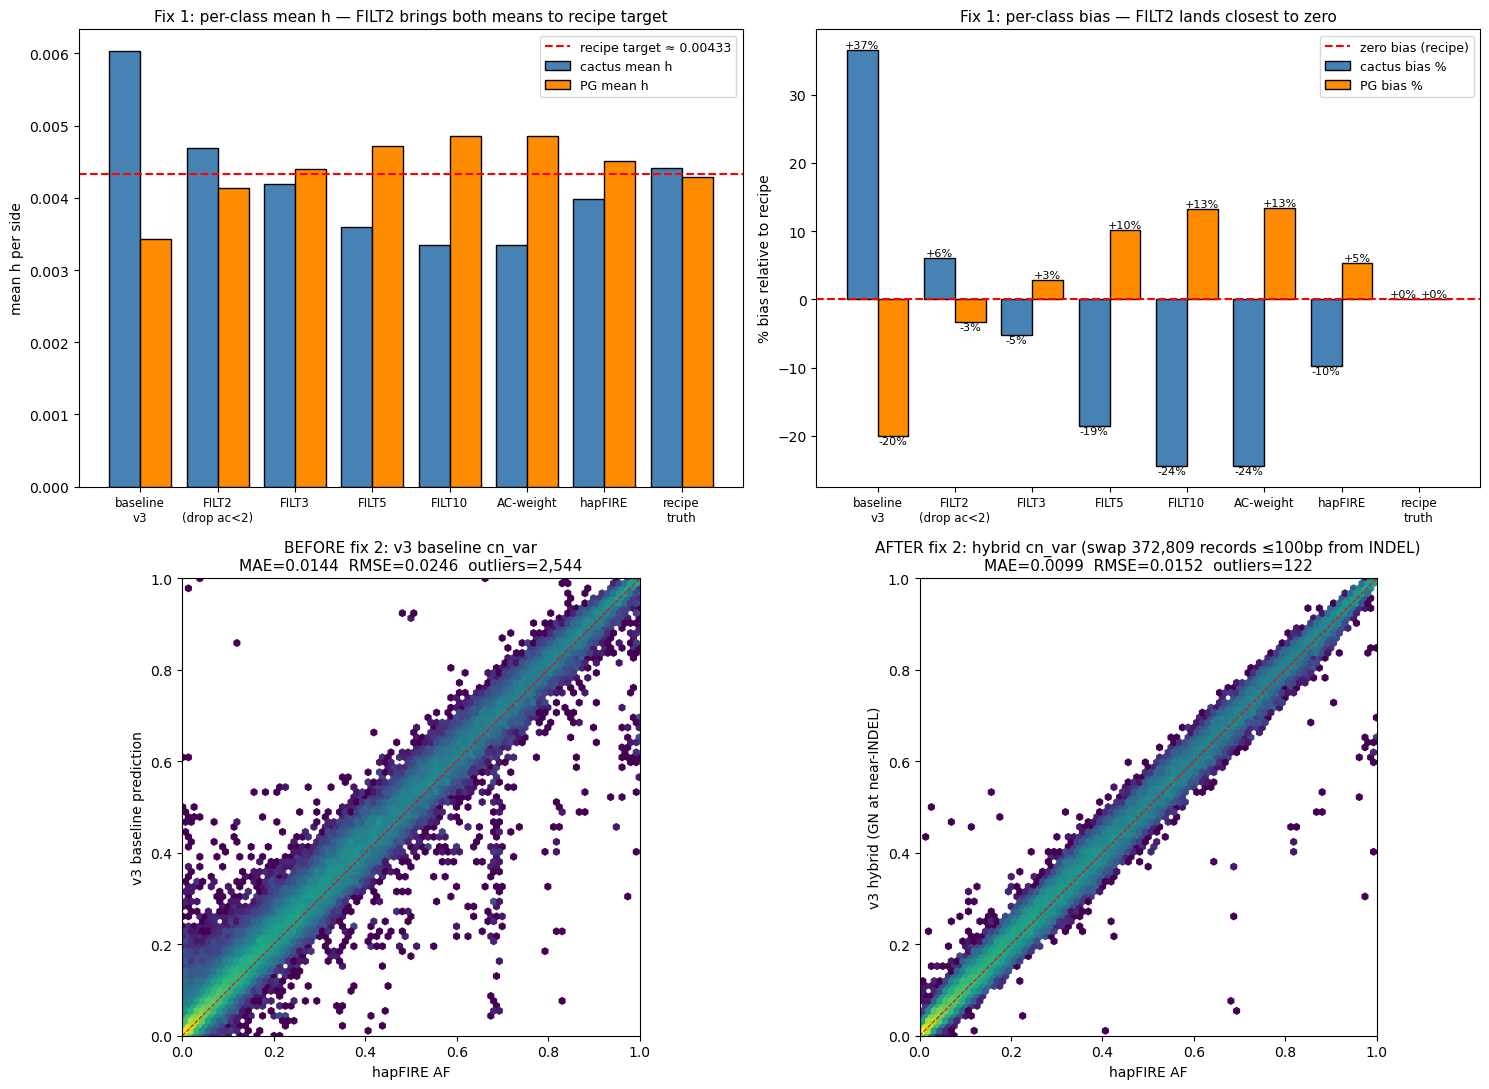

In [71]:
# Fix 1 figure: per-class mean h for baseline + filt2 variants + hapFIRE + recipe truth
# (Removed bottom row "Fix 2 hybrid cn_var" hexbins — that approach was overfitting; not a principled fix)

fig = plt.figure(figsize=(15, 5))
UNIFORM = 1/231

# Panel L: per-class mean h
ax = fig.add_subplot(1, 2, 1)
methods   = ['baseline\nv3',    'FILT2\n(drop ac<2)', 'FILT3', 'FILT5', 'FILT10', 'AC-weight', 'hapFIRE', 'recipe\ntruth']
h_list    = [h_baseline,      h_filt2,             h_filt3, h_filt5, h_filt10, h_acw, h_hf_local, h_truth_local]
cactus_means = [h[is_cactus_arr].mean() for h in h_list]
pg_means     = [h[~is_cactus_arr].mean() for h in h_list]
x = np.arange(len(methods))
ax.bar(x - 0.2, cactus_means, width=0.4, color='steelblue', edgecolor='black', label='cactus mean h')
ax.bar(x + 0.2, pg_means,     width=0.4, color='darkorange', edgecolor='black', label='PG mean h')
ax.axhline(UNIFORM, color='red', ls='--', lw=1.5, label=f'recipe target ≈ {UNIFORM:.5f}')
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=0, fontsize=8.5)
ax.set_ylabel('mean h per side')
ax.set_title('Per-class mean h — FILT2 brings both means to recipe target', fontsize=11)
ax.legend(loc='upper right', fontsize=9)

# Panel R: per-class bias percent
ax = fig.add_subplot(1, 2, 2)
cactus_bias = [(h[is_cactus_arr].mean()/h_truth_local[is_cactus_arr].mean() - 1)*100 for h in h_list]
pg_bias     = [(h[~is_cactus_arr].mean()/h_truth_local[~is_cactus_arr].mean() - 1)*100 for h in h_list]
ax.bar(x - 0.2, cactus_bias, width=0.4, color='steelblue', edgecolor='black', label='cactus % bias')
ax.bar(x + 0.2, pg_bias,     width=0.4, color='darkorange', edgecolor='black', label='PG % bias')
ax.axhline(0, color='red', ls='--', lw=1.5)
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=0, fontsize=8.5)
ax.set_ylabel('% bias relative to recipe truth')
ax.set_title('Per-class % bias vs recipe — FILT2 within ±10%', fontsize=11)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


### Reading the figure

**Fix 1 (filt2) reduces the cactus h-class-bias:**

Left panel: per-class mean h for each strategy. The red dashed line is the recipe target ≈ 1/231. Baseline shows the classic cactus-tall / PG-short bias. FILT2 brings BOTH bars (cactus blue, PG orange) close to the target line. More aggressive filters and ac-weight over-correct.

Right panel: same data expressed as % bias relative to recipe truth. **FILT2 is the configuration where both classes are within ±10% of zero**. Other strategies either over-credit cactus (baseline) or over-credit PG (filt5, filt10, ac-weight).

Note: improving h-class-balance toward the recipe target is a SEEDMIX-only signal. The recipe specifies uniform 1/231, but the realized SEEDMIX composition may have germination/extraction biases. Evolved GrENE-Net samples will be non-uniform by design (selection-driven). Regularizing toward uniform is therefore not a production fix; filt2 is class-agnostic and is the production residual-bias fix.

The per-SNP AF outliers (the bottom-row content we previously demonstrated as 'Fix 2 hybrid cn_var') has been removed — that approach is not a principled fix.


## Summary — what we found, what's fixed, what's open

**The cactus h-class-bias is real on SEEDMIX and partially fixed by filt2.**

| metric | baseline | filt2 |
|---|---:|---:|
| Σh on cactus (truth = 0.346) | 0.482 (+39%) | 0.375 (+8%) |
| Σh on PG    (truth = 0.654) | 0.518 (−21%) | 0.625 (−4%) |
| eff_n_founders (truth = 231 if uniform) | 128 | 134 |

filt2 is the production residual-bias fix. AC-weight and per-bubble cap variants either over-correct or trade h-balance for per-record AF accuracy (anti-correlated; see cross-session memory `feedback_dont_optimize_h_bias.md`).

**The per-SNP AF outlier problem is real but mechanism is open.**

Diagnostics G–I localized it to `cn_var_v3` at SNPs adjacent to INDELs/SVs. ~95% of outliers within 100bp of an INDEL/SV. **The mechanism is NOT yet understood.** An earlier hypothesis about `bcftools norm -m -any` left-alignment was directly tested by looking at sibling atomic records within the same cactus snarl ID; the test returned 0% co-occurrence — indicating that hypothesis was wrong or the atomization removed the structure the test relied on. Other candidate mechanisms (PG genotyping uncertainty near indels, deletion-bearing path encoding) have not yet been tested.

**The previously-described "Fix 2 hybrid cn_var" has been REMOVED from this analysis.** Replacing v3 cn_var rows with GrENE-Net cn_var rows at SNPs near INDELs is overfitting — it patches the panel using another panel's data at exactly the records where we already know they disagree. Not a principled fix.

**Hypotheses confirmed false:**
- Low-coverage Cao 2011 GAII PG founders → filter didn't help (Diagnostic E)
- Broken Hau-0 (7164) assembly → filter didn't help (Diagnostic F)
- 69-extras-driven PG noise → wrong direction (Diagnostic J; PG-only records are CLEANEST)

**Hypotheses confirmed true:**
- Bug is in `cn_var_v3`, not in `h_v3` (Diagnostic G)
- Outliers concentrate near INDELs/SVs in v3 (Diagnostic I)

**What's next:** characterize the actual mechanism at the founder-genotype level (which bubble paths, which graph topology) before any panel rebuild.
